# Problema

Una entidad bancaria contrata a una empresa de marketing encargada de contactar telefónicamente a posibles clientes para determinar si están interesados o no en adquirir un certificado de depósito a término con el banco.

¿Qué perfil tienen los clientes con mayor potencial de conversión?

# El set de datos después de la limpieza

La información recolectada por la empresa de mercadeo se encuentra en un archivo CSV (`dataset_banco_clean.csv`) con 45189 filas y 17 columnas.

Cada registro contiene 16 características (las primeras 16 columnas) y una categoría ("yes" o "no" dependiendo de si la persona está o no interesada en adquirir el producto). Las columnas son:

1. "age":  edad (numérica)
2. "job": tipo de trabajo (categórica: "admin.", "unknown", "unemployed", "management", "housemaid", "entrepreneur", "student", "blue-collar","self-employed", "retired", "technician", "services")
3. "marital": estado civil (categórica: "married", "divorced", "single")
4. "education": nivel educativo (categórica: "unknown", "secondary", "primary", "tertiary")
5. "default": si dejó de pagar sus obligaciones (categórica: "yes", "no")
6. "balance": saldo promedio anual en euros (numérica)
7. "housing": ¿tiene o no crédito hipotecario? (categórica: "yes", "no")
8. "loan": ¿tiene créditos de consumo? (categórica: "yes", "no")
9. "contact": medio a través del cual fue contactado (categórica: "unknown", "telephone", "cellular")
10. "day": último día del mes en el que fue contactada (numérica)
11. "month": último mes en el que fue contactada (categórica: "jan", "feb", "mar", ..., "nov", "dec")
12. "duration": duración (en segundos) del último contacto (numérica)
13. "campaign": número total de veces que fue contactada durante la campaña (numérica)
14. "pdays": número de días transcurridos después de haber sido contactado antes de la campaña actual (numérica. -1 indica que no fue contactado previamente)
15. "previous": número de veces que ha sido contactada antes de esta campaña (numérica)
16. "poutcome": resultado de la campaña de marketing anterior (categórica: "unknown", "other", "failure", "success")
17. "y": categoría ¿el cliente se suscribió a un depósito a término? (categórica: "yes", "no")

In [10]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive


In [3]:
ruta = "dataset_banco_clean (1).csv"
data = pd.read_csv(ruta)

In [4]:
print(data.shape)
data.head()

(45189, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no


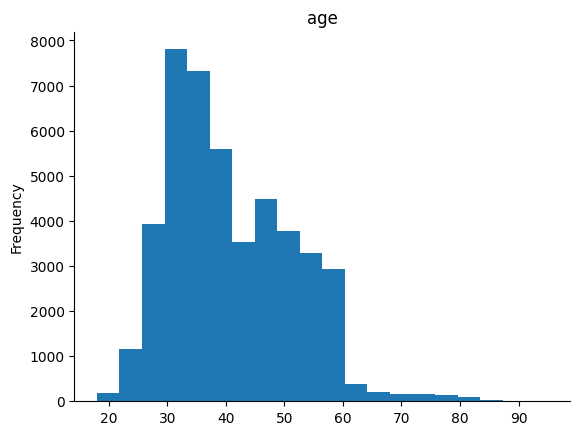

In [5]:
# @title age

from matplotlib import pyplot as plt
data['age'].plot(kind='hist', bins=20, title='age')
plt.gca().spines[['top', 'right',]].set_visible(False)

# Análisis exploratorio

La idea es usar herramientas estadísticas y de visualización para:

- Crear un mapa mental del set de datos (entenderlo)
- Empezar a encontrar respuestas a la pregunta planteada inicialmente (¿qué perfil tienen los clientes con mayor potencial de conversión?)

Llevaremos a cabo estas fases:

1. Análisis de cada variable de manera individual
2. Análisis univariado: relación de cada variable predictora con la variable a predecir
3. Análisis bivariado: relación de pares de variables predictoras con la variable a predecir

Para cada una de ellas generar un pequeño resumen

### Estadistica descriptiva variables numericas

In [6]:
## A completar
desc = data.describe()
desc

,age,balance,day,duration,campaign,pdays,previous
count,45189.000000,45189.000000,45189.000000,45189.000000,45189.000000,45189.000000,45189.000000
mean,40.936445,1374.012149,15.807188,258.115006,2.763283,40.178893,0.574166
std,10.618502,3924.370039,8.322549,257.349601,3.096579,100.107295,1.907950
min,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,527532.000000,31.000000,4918.000000,63.000000,871.000000,58.000000


In [8]:
categorical_columns = data.select_dtypes(include=['object']).columns

<ipython-input-11-390424bda0cf>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column, data=data, ax=ax[i], order = data[column].value_counts().index, palette='viridis')
<ipython-input-11-390424bda0cf>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column, data=data, ax=ax[i], order = data[column].value_counts().index, palette='viridis')
<ipython-input-11-390424bda0cf>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column, data=data, ax=ax[i], order = data[column].value_counts().index, palette='viridis')
<ipython-input-11-3

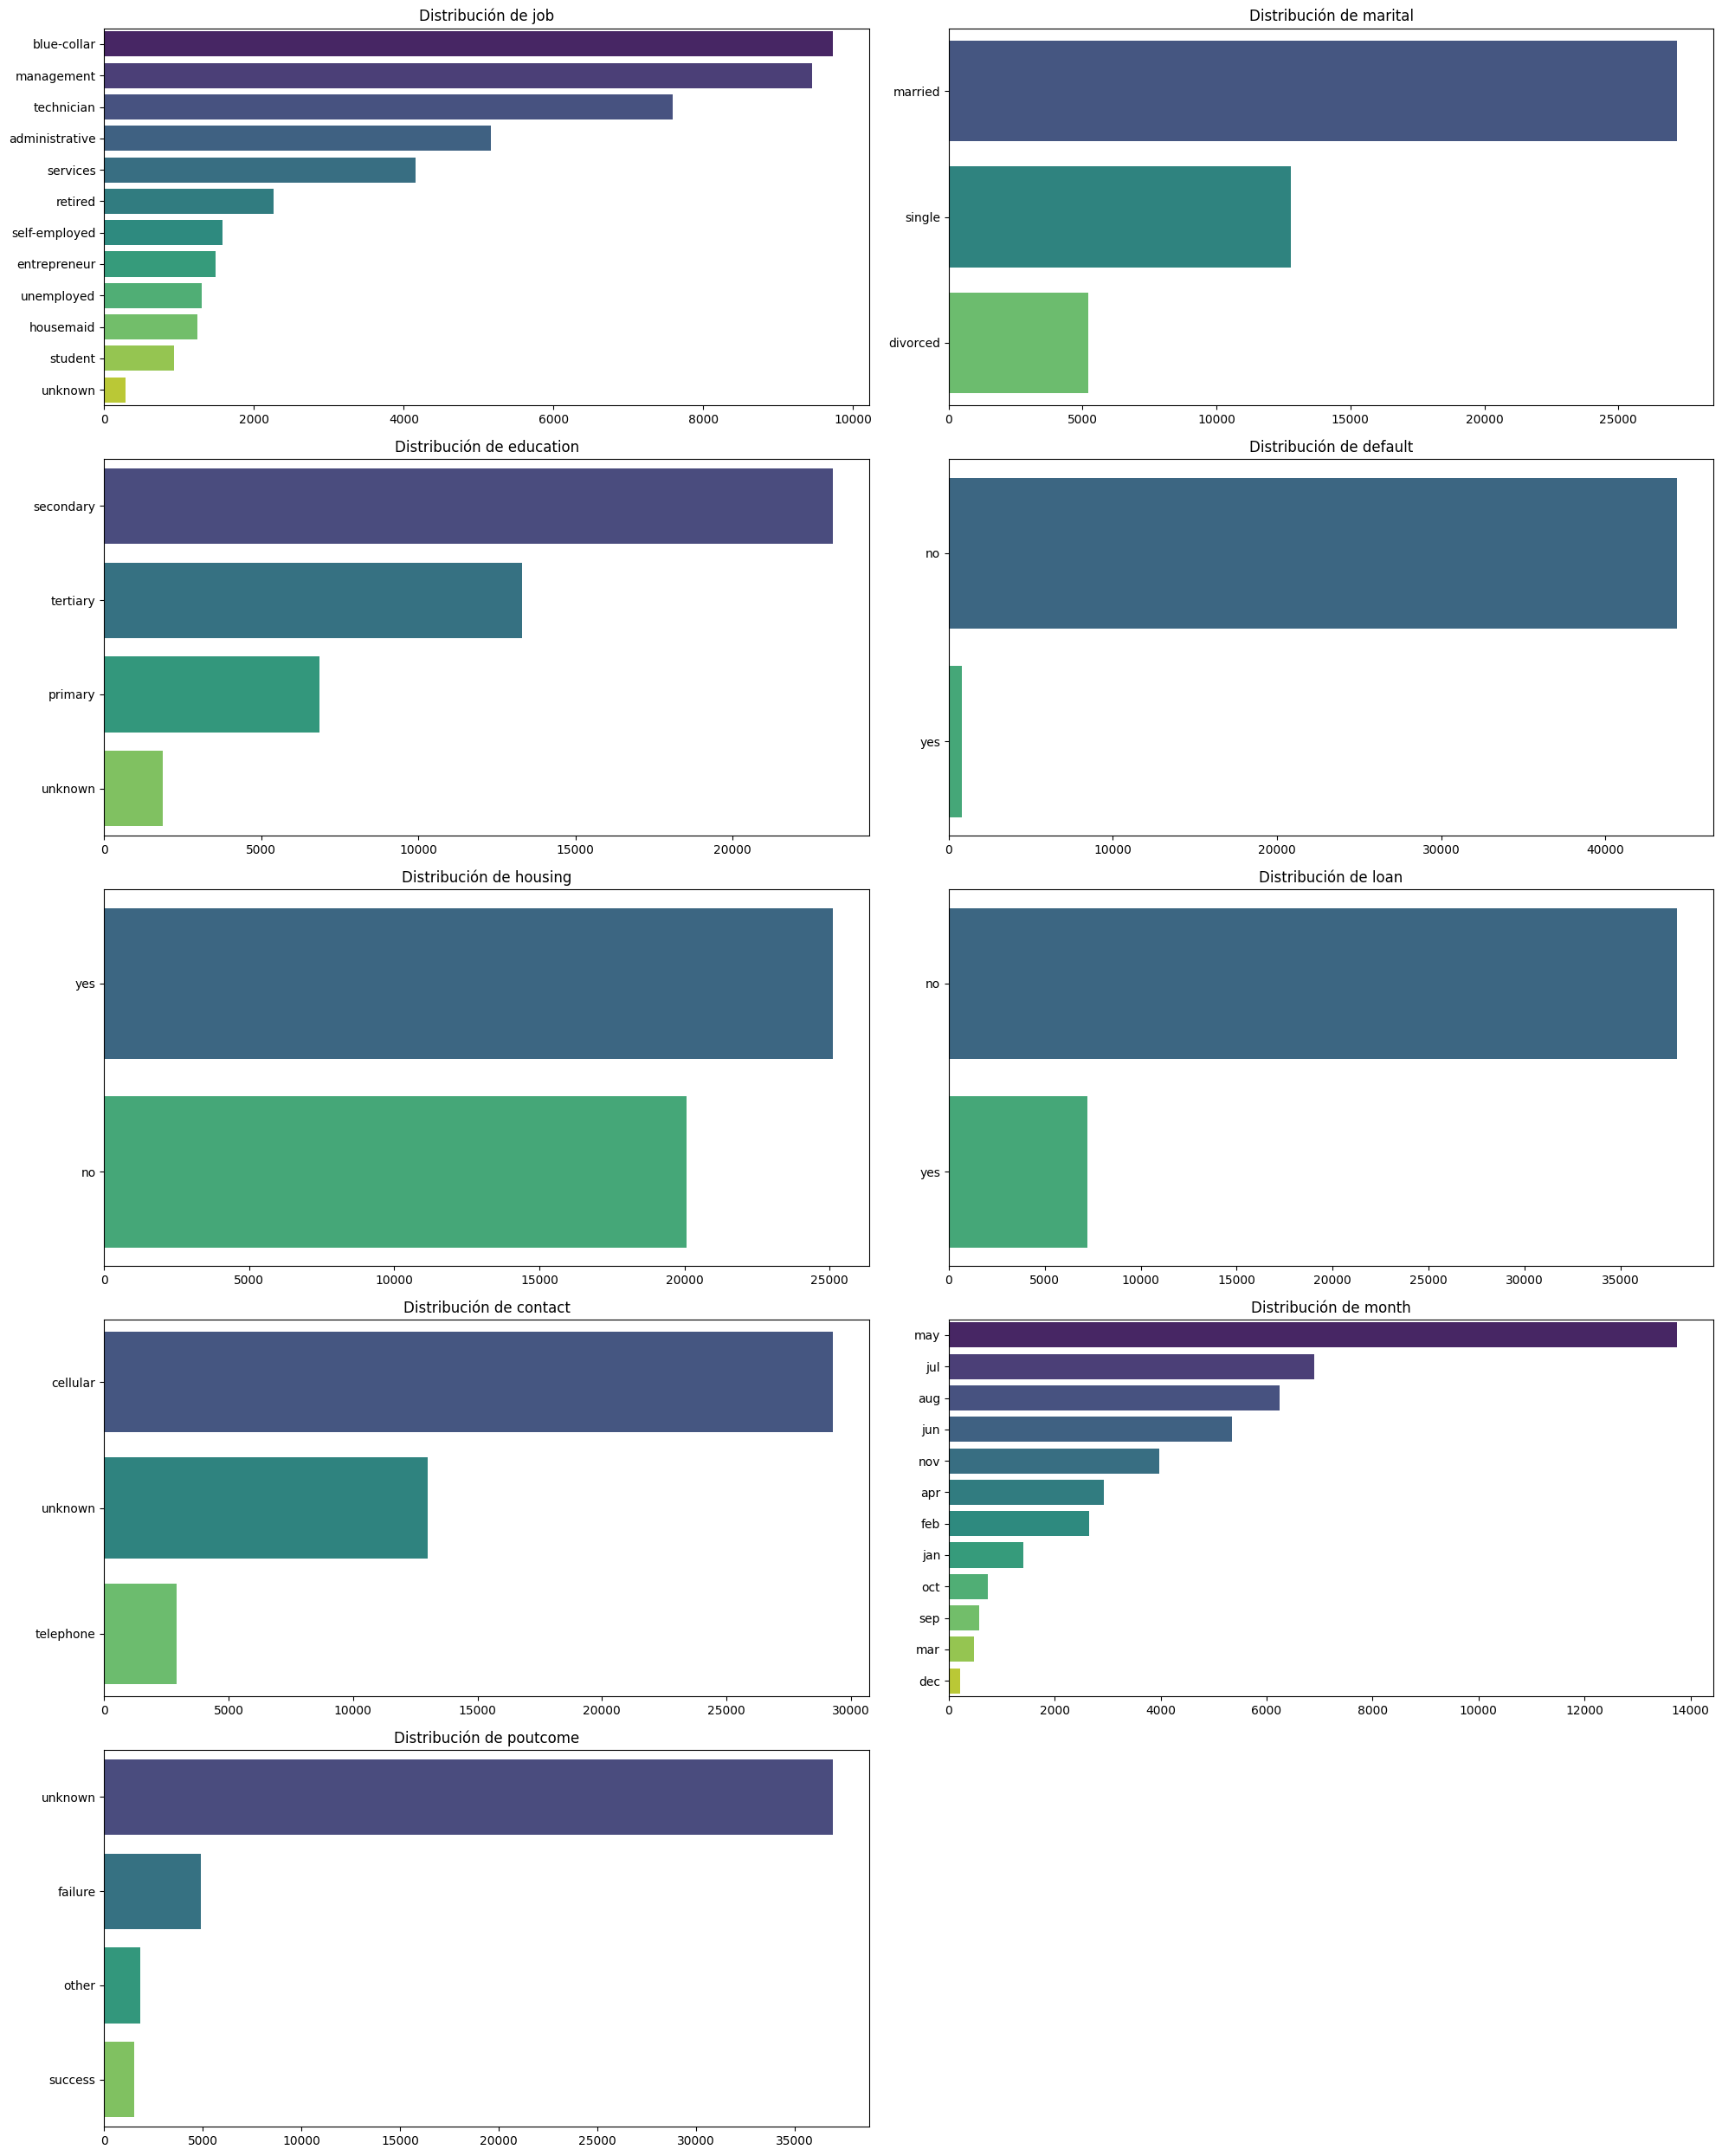

In [11]:
# Gráficos de barras para variables categóricas
fig, ax = plt.subplots(5, 2, figsize=(20, 25))
ax = ax.flatten()

for i, column in enumerate(categorical_columns[:-1]): # Excluir 'y' de la exploración
    sns.countplot(y=column, data=data, ax=ax[i], order = data[column].value_counts().index, palette='viridis')
    ax[i].set_title(f'Distribución de {column}')
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')

# Eliminar el espacio sobrante para una variable categórica que no se usa
fig.delaxes(ax[-1])

plt.tight_layout()
plt.show()


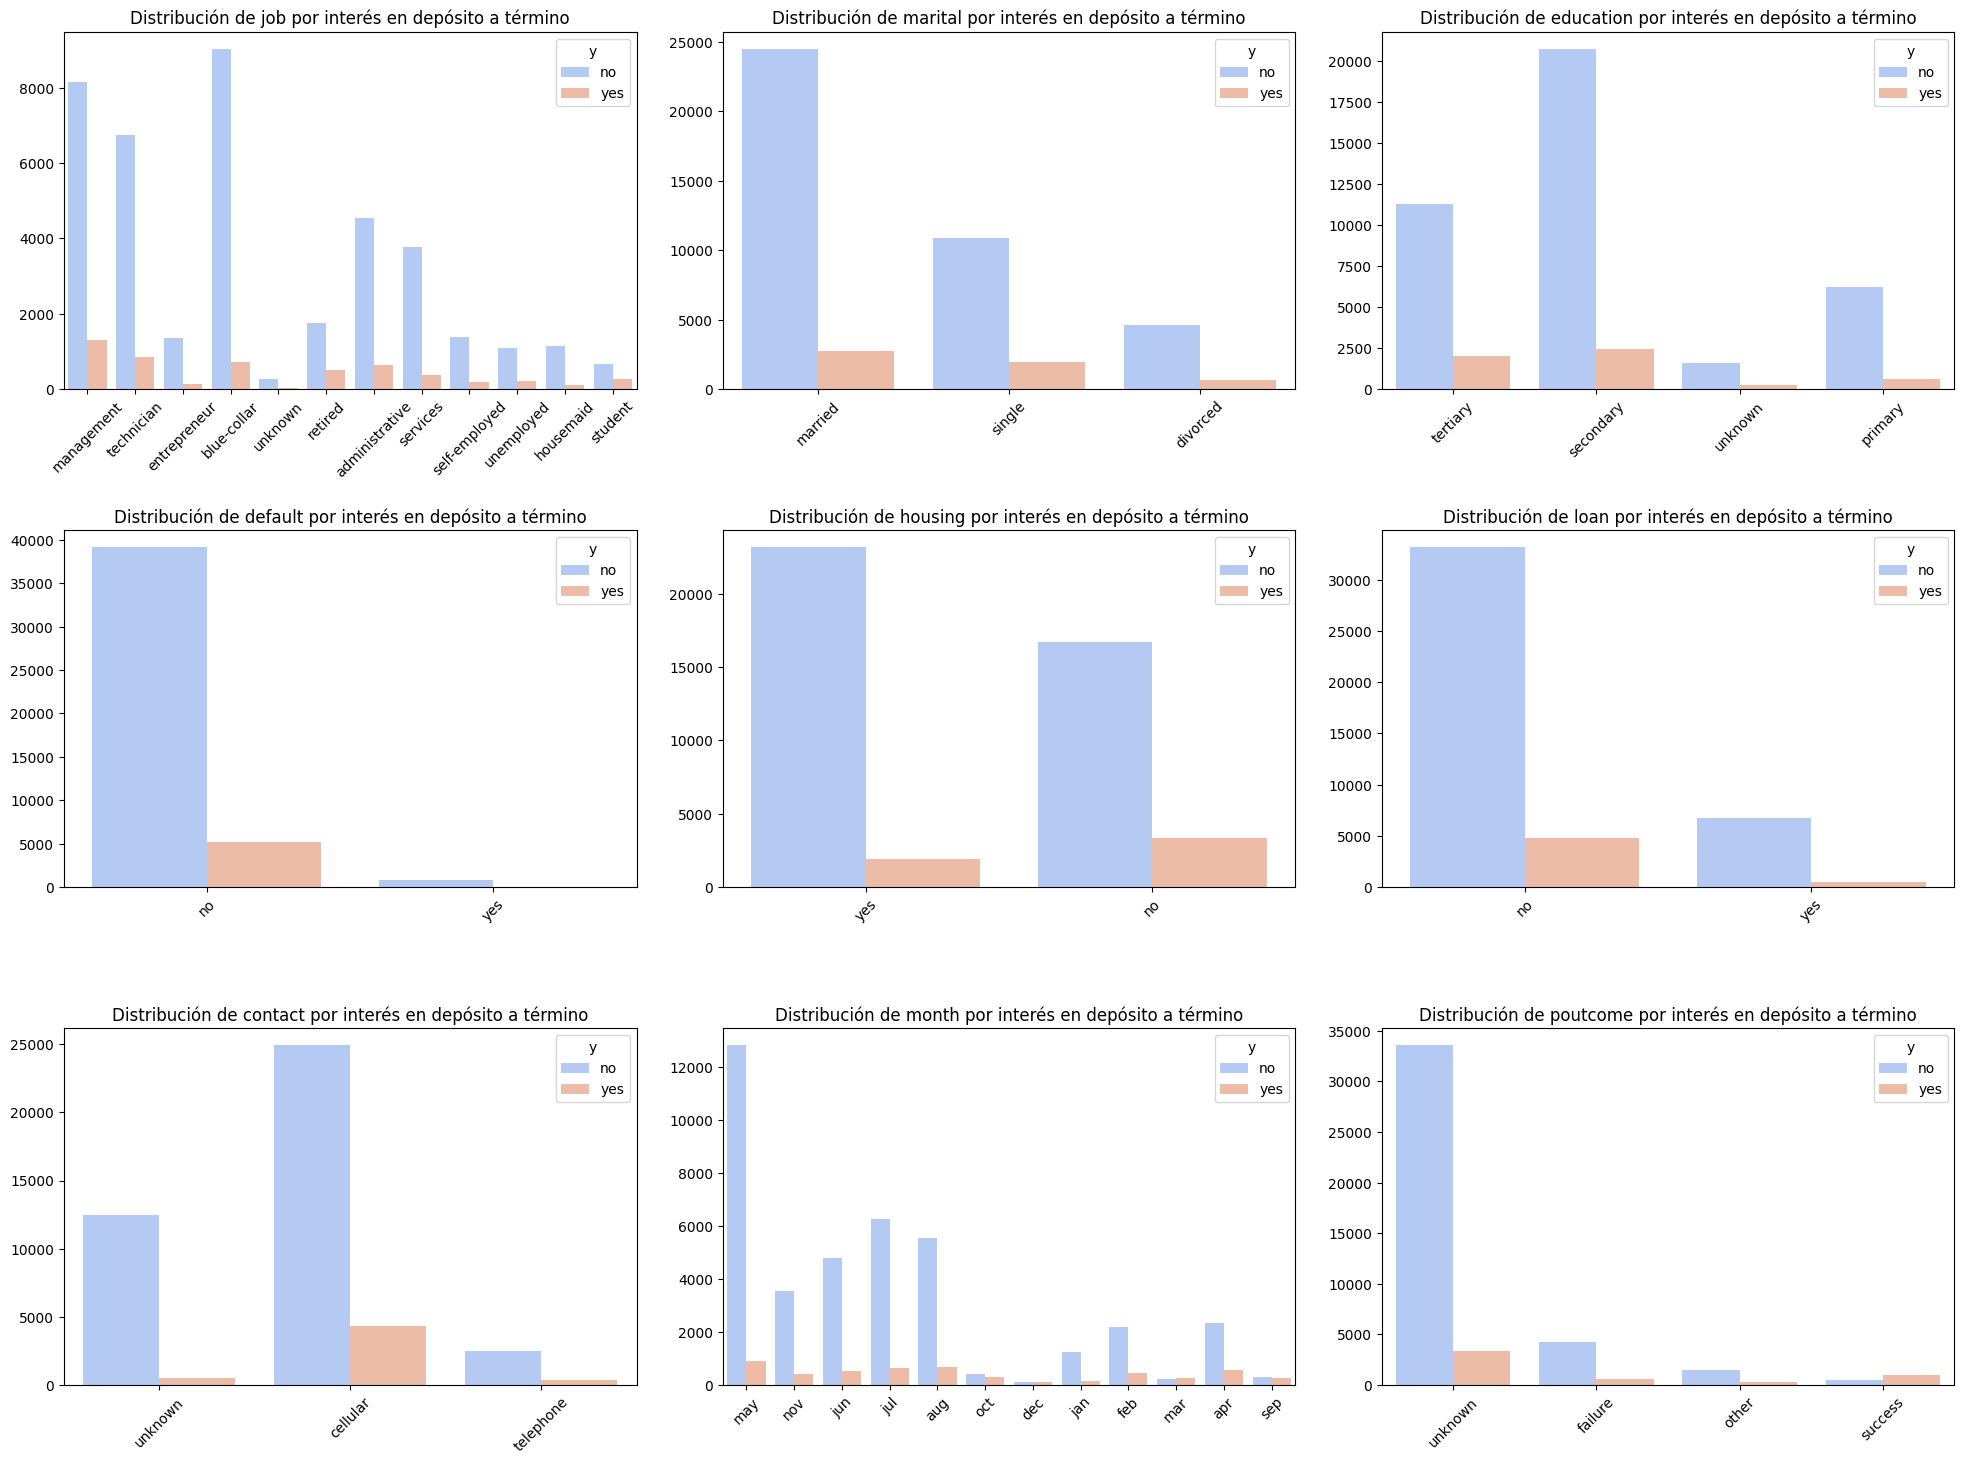

In [12]:
# Análisis de las variables categóricas en relación a la variable objetivo "y"
fig, ax = plt.subplots(3, 3, figsize=(20, 15))

for i, column in enumerate(categorical_columns[:-1]): # Excluir 'y' de la exploración
    row, col = i // 3, i % 3
    sns.countplot(x=column, hue='y', data=data, ax=ax[row, col], palette='coolwarm')
    ax[row, col].set_title(f'Distribución de {column} por interés en depósito a término')
    ax[row, col].set_xlabel('')
    ax[row, col].set_ylabel('')
    ax[row, col].tick_params(axis='x', rotation=45)

fig.tight_layout(pad=2.0)
plt.show()

# Conclusiones
## UNIVARIADO
POUTCOME, JOB, grupos_BALANCE, grupos_EDAD, DEFAULT, HOUSING, MARTIAL, EDUCACION

BUSCAR USUARIO TARGET

Relación de la columna job con la variable objetivo 'y'
y                  no   yes    All
job                               
administrative   4537   631   5168
blue-collar      9020   707   9727
entrepreneur     1363   123   1486
housemaid        1131   109   1240
management       8155  1300   9455
retired          1748   515   2263
self-employed    1391   187   1578
services         3783   369   4152
student           668   269    937
technician       6753   839   7592
unemployed       1101   202   1303
unknown           254    34    288
All             39904  5285  45189




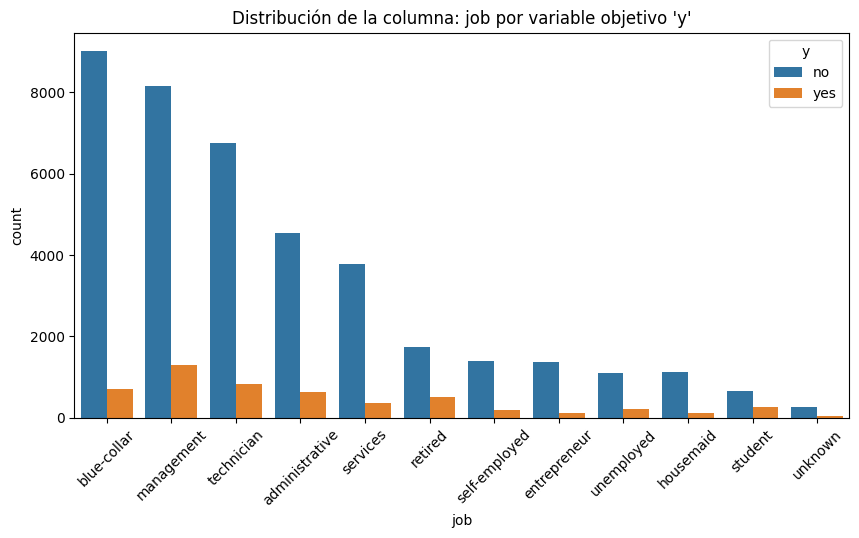

Relación de la columna marital con la variable objetivo 'y'
y            no   yes    All
marital                     
divorced   4582   622   5204
married   24448  2752  27200
single    10874  1911  12785
All       39904  5285  45189




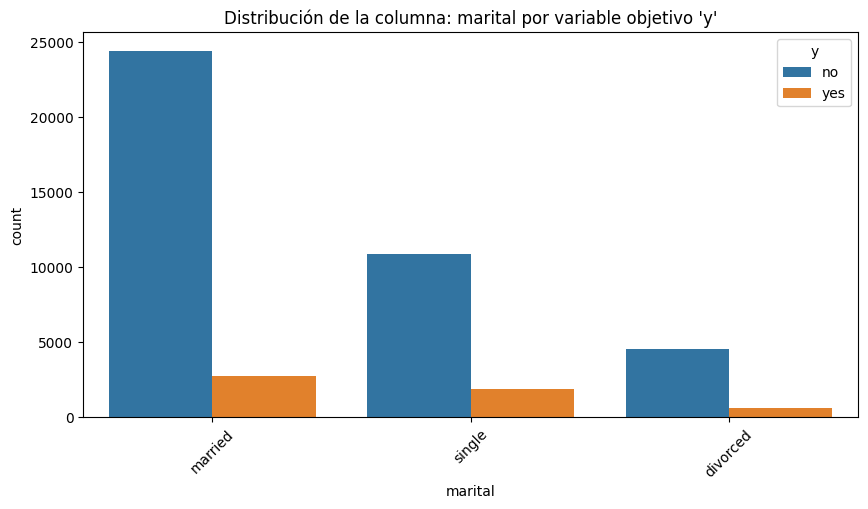

Relación de la columna education con la variable objetivo 'y'
y             no   yes    All
education                    
primary     6257   590   6847
secondary  20739  2448  23187
tertiary   11303  1995  13298
unknown     1605   252   1857
All        39904  5285  45189




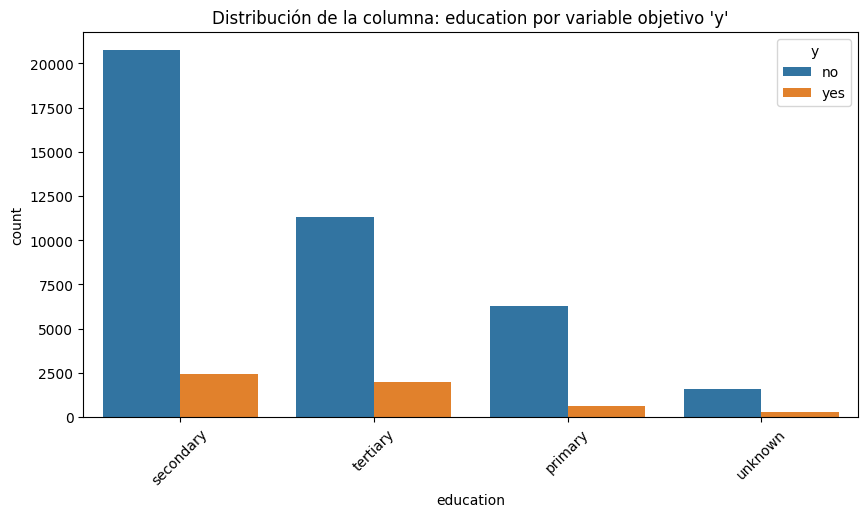

Relación de la columna default con la variable objetivo 'y'
y           no   yes    All
default                    
no       39141  5233  44374
yes        763    52    815
All      39904  5285  45189




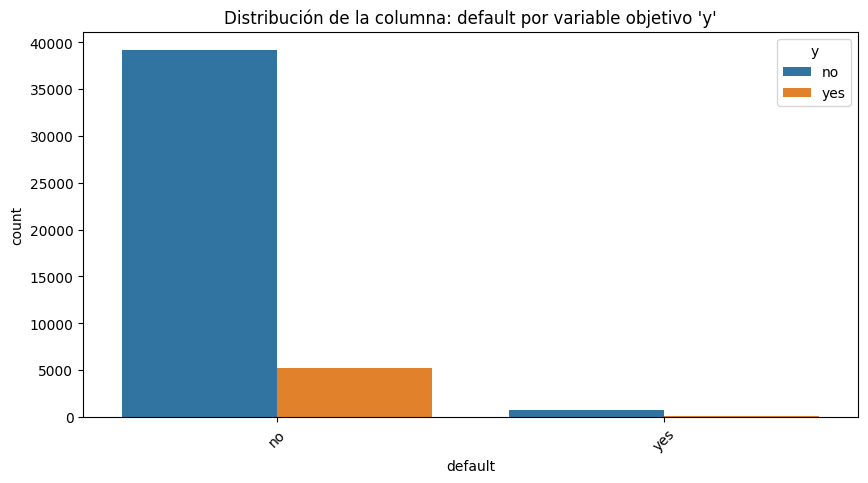

Relación de la columna housing con la variable objetivo 'y'
y           no   yes    All
housing                    
no       16726  3352  20078
yes      23178  1933  25111
All      39904  5285  45189




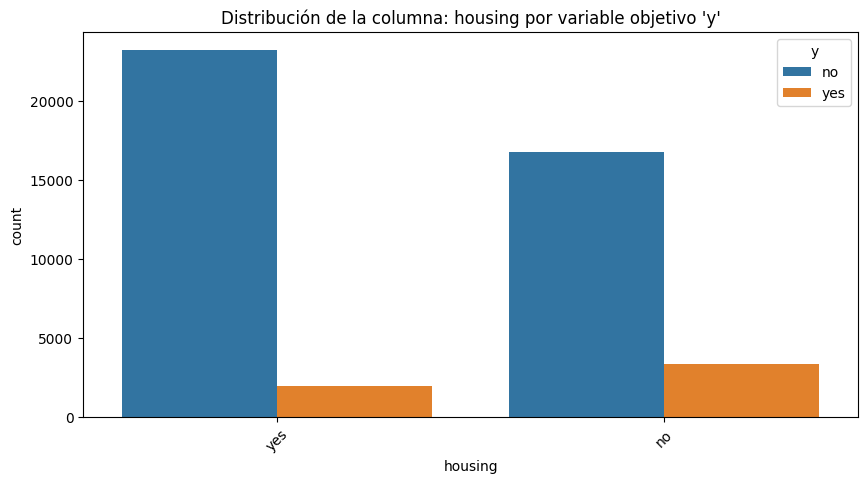

Relación de la columna loan con la variable objetivo 'y'
y        no   yes    All
loan                    
no    33147  4801  37948
yes    6757   484   7241
All   39904  5285  45189




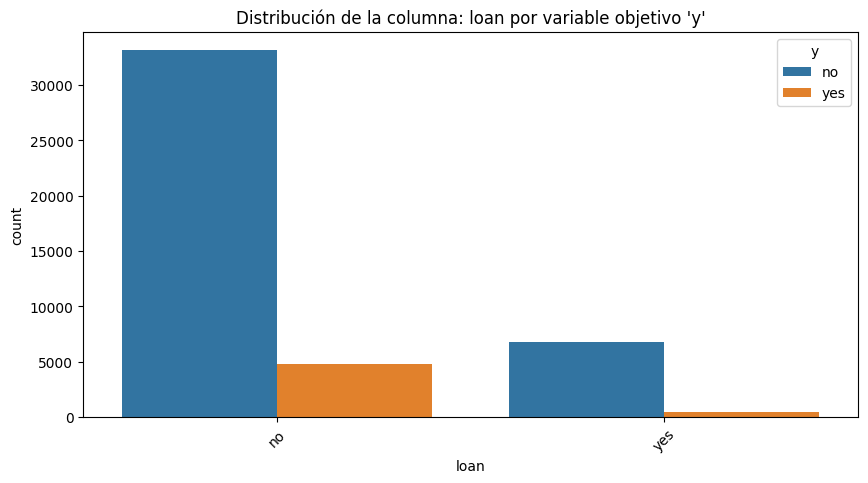

Relación de la columna contact con la variable objetivo 'y'
y             no   yes    All
contact                      
cellular   24907  4367  29274
telephone   2515   389   2904
unknown    12482   529  13011
All        39904  5285  45189




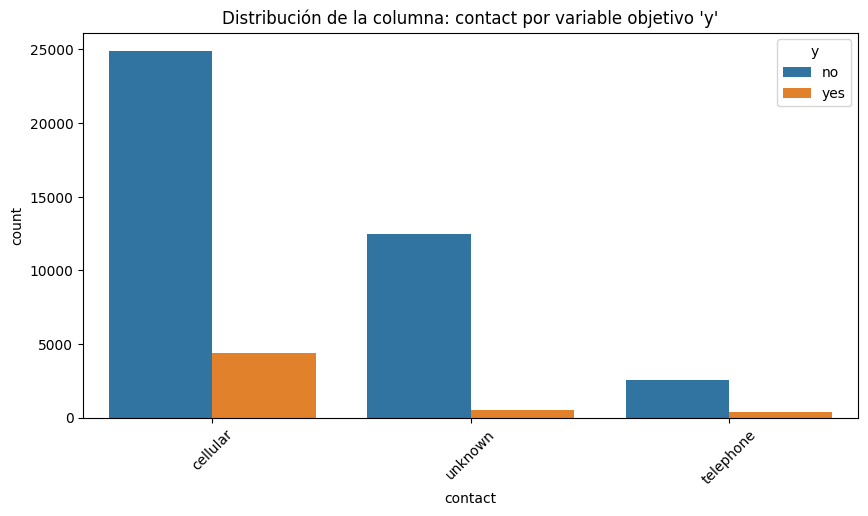

Relación de la columna month con la variable objetivo 'y'
y         no   yes    All
month                    
apr     2355   576   2931
aug     5558   688   6246
dec      114   100    214
feb     2207   441   2648
jan     1260   142   1402
jul     6268   627   6895
jun     4795   546   5341
mar      229   248    477
may    12826   922  13748
nov     3567   403   3970
oct      415   323    738
sep      310   269    579
All    39904  5285  45189




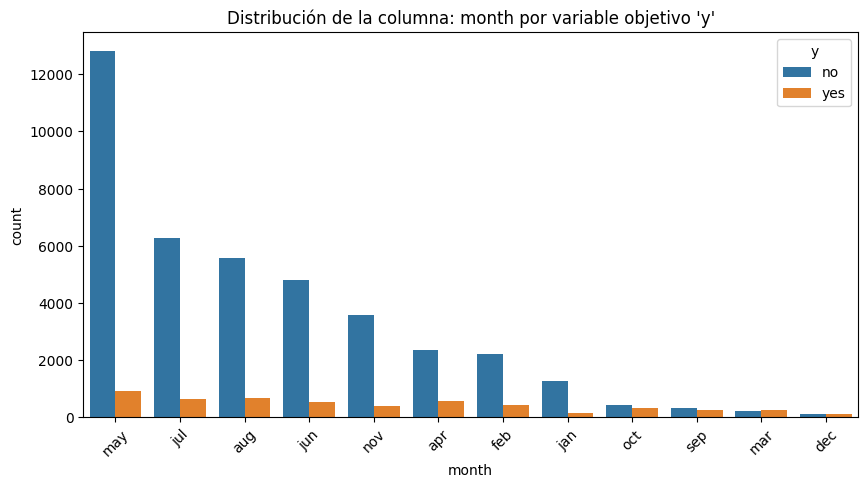

Relación de la columna poutcome con la variable objetivo 'y'
y            no   yes    All
poutcome                    
failure    4281   617   4898
other      1531   306   1837
success     533   978   1511
unknown   33559  3384  36943
All       39904  5285  45189




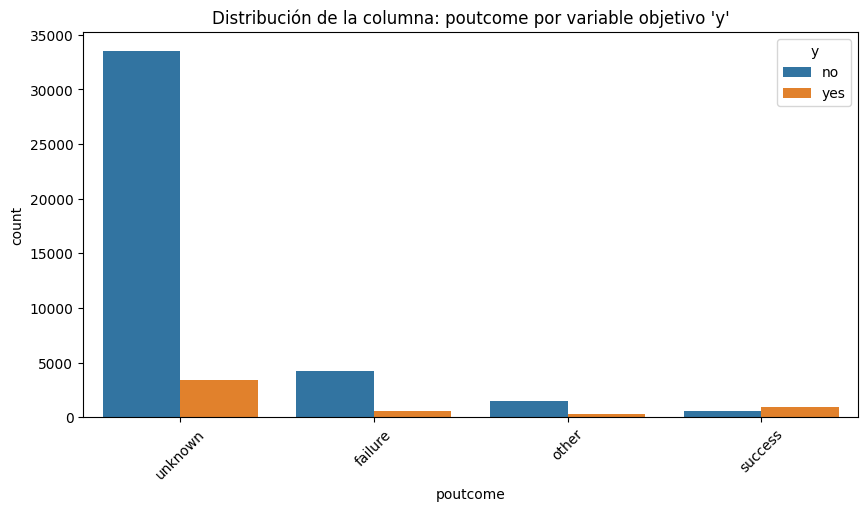

Relación de la columna y con la variable objetivo 'y'
y       no   yes    All
y                      
no   39904     0  39904
yes      0  5285   5285
All  39904  5285  45189




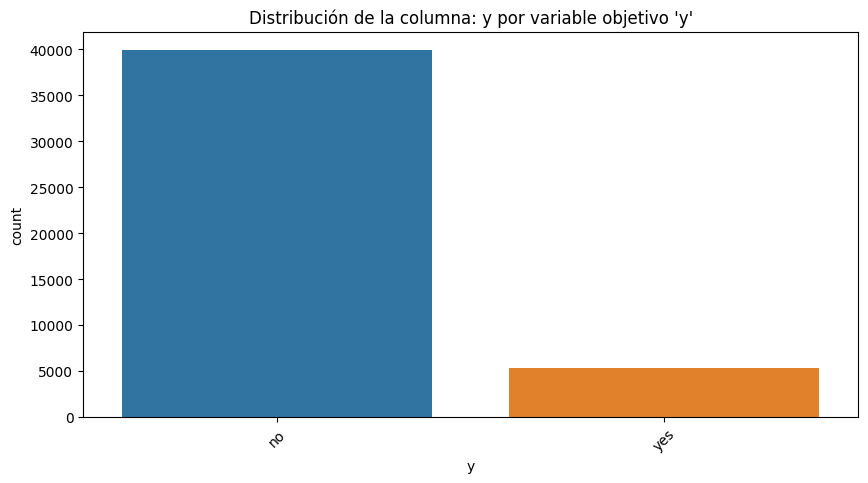

Relación de la columna age con la variable objetivo 'y'
       count       mean        std   min   25%   50%   75%   max
y                                                               
no   39904.0  40.839891  10.173157  18.0  33.0  39.0  48.0  95.0
yes   5285.0  41.665468  13.494304  18.0  31.0  38.0  50.0  95.0




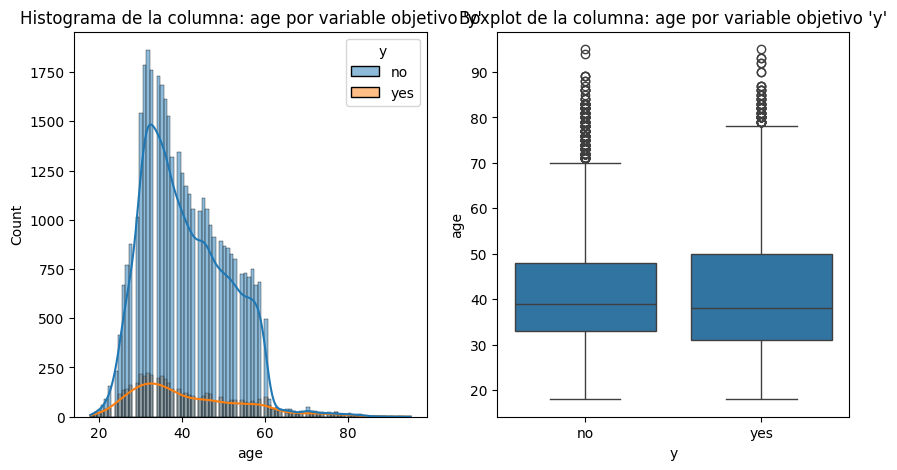

Relación de la columna balance con la variable objetivo 'y'
       count         mean          std     min    25%    50%     75%       max
y                                                                             
no   39904.0  1317.011478  3973.460509 -8019.0   58.0  417.0  1345.0  527532.0
yes   5285.0  1804.391485  3502.278416 -3058.0  209.0  732.0  2159.0   81204.0




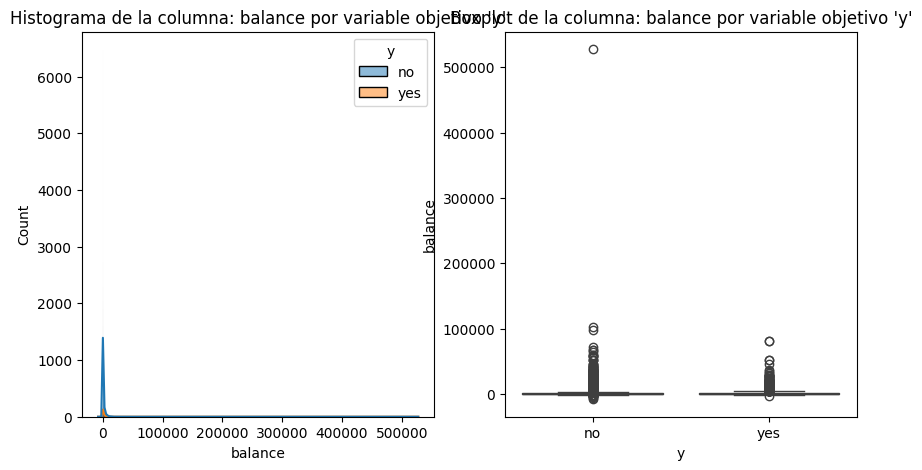

Relación de la columna day con la variable objetivo 'y'
       count       mean       std  min  25%   50%   75%   max
y                                                            
no   39904.0  15.892943  8.294662  1.0  8.0  16.0  21.0  31.0
yes   5285.0  15.159697  8.503097  1.0  8.0  15.0  22.0  31.0




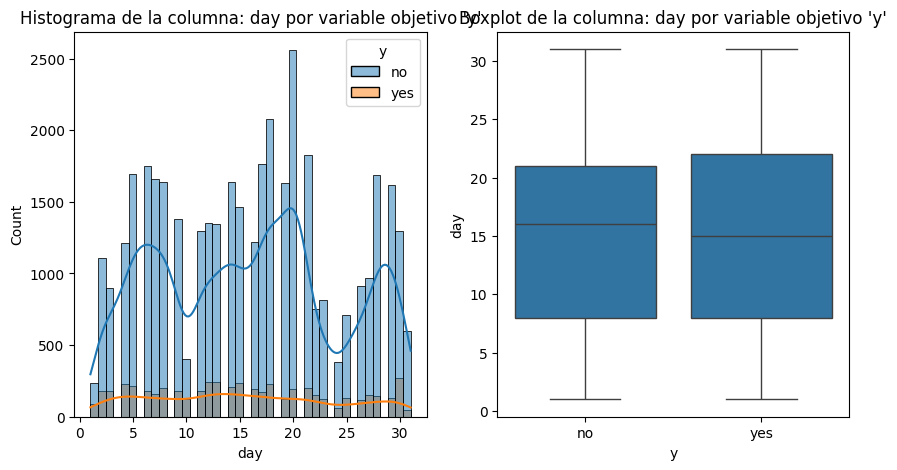

Relación de la columna duration con la variable objetivo 'y'
       count        mean         std  min    25%    50%    75%     max
y                                                                     
no   39904.0  221.207949  207.396917  1.0   95.0  164.0  279.0  4918.0
yes   5285.0  536.778997  391.919466  8.0  244.0  426.0  724.0  3881.0




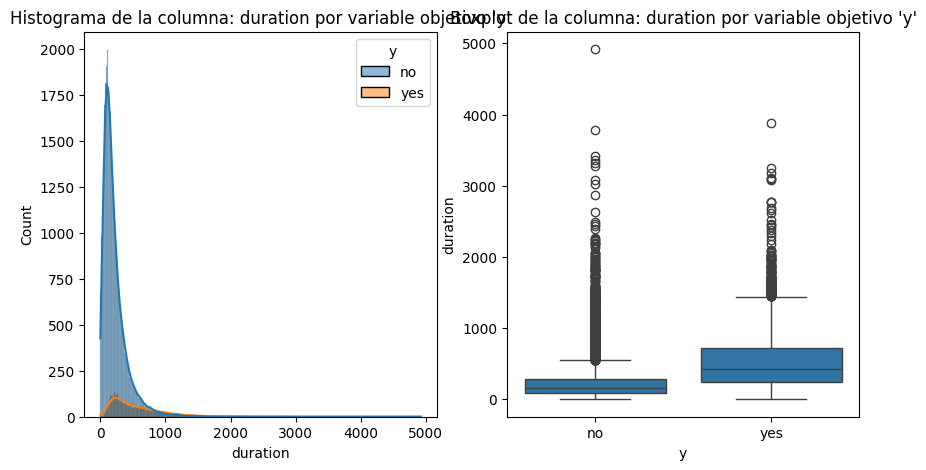

Relación de la columna campaign con la variable objetivo 'y'
       count      mean       std  min  25%  50%  75%   max
y                                                         
no   39904.0  2.845680  3.211144  1.0  1.0  2.0  3.0  63.0
yes   5285.0  2.141154  1.922254  1.0  1.0  2.0  3.0  32.0




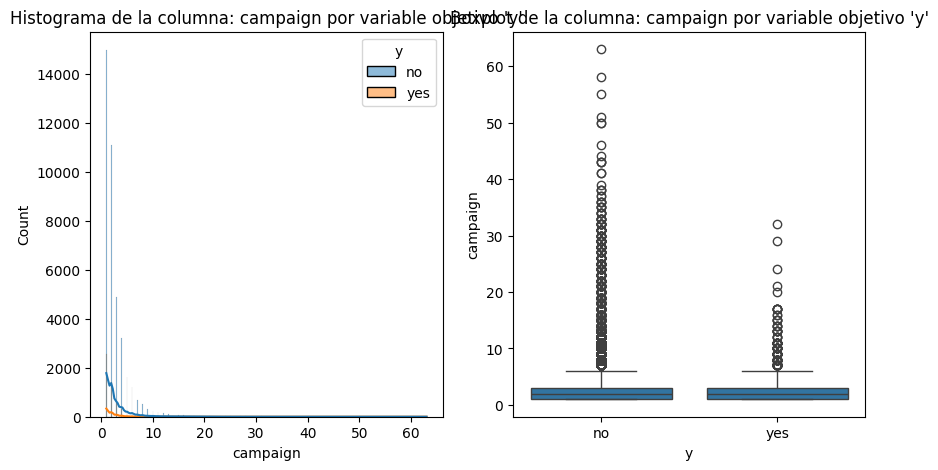

Relación de la columna pdays con la variable objetivo 'y'
       count       mean         std  min  25%  50%   75%    max
y                                                              
no   39904.0  36.409959   96.745141 -1.0 -1.0 -1.0  -1.0  871.0
yes   5285.0  68.635951  118.761070 -1.0 -1.0 -1.0  98.0  854.0




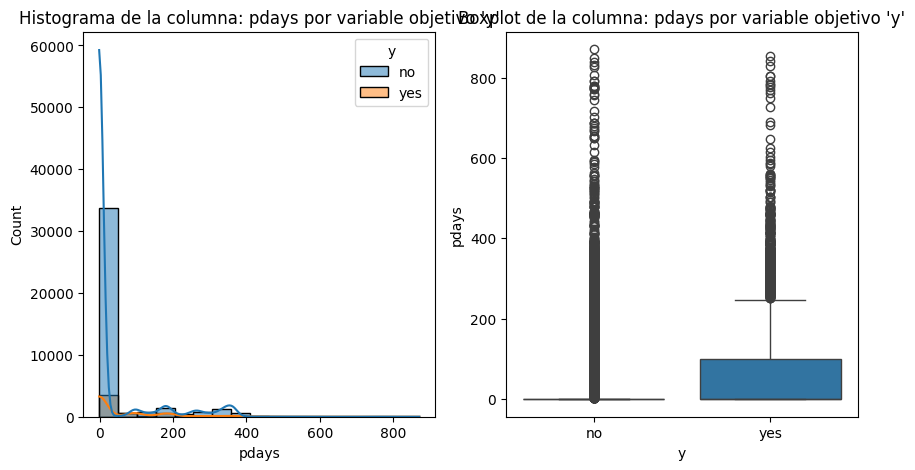

Relación de la columna previous con la variable objetivo 'y'
       count      mean       std  min  25%  50%  75%   max
y                                                         
no   39904.0  0.495314  1.790685  0.0  0.0  0.0  0.0  51.0
yes   5285.0  1.169536  2.552407  0.0  0.0  0.0  1.0  58.0




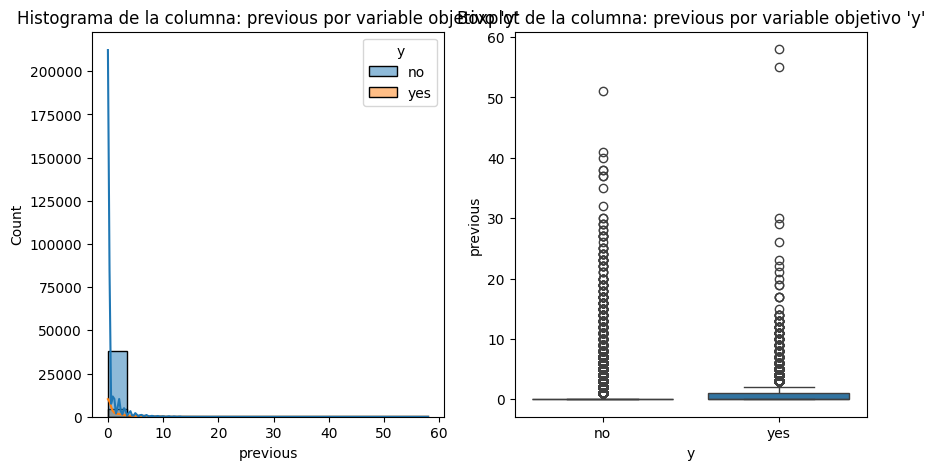

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Análisis univariado para variables categóricas
columnas_categoricas = data.select_dtypes(include=['object']).columns

for columna in columnas_categoricas:
    print(f"Relación de la columna {columna} con la variable objetivo 'y'")
    print(pd.crosstab(data[columna], data['y'], margins=True))
    print("\n")

    # Visualización
    plt.figure(figsize=(10, 5))
    sns.countplot(x=columna, hue='y', data=data, order=data[columna].value_counts().index)
    plt.title(f"Distribución de la columna: {columna} por variable objetivo 'y'")
    plt.xticks(rotation=45)
    plt.show()

# Análisis univariado para variables numéricas
columnas_numericas = data.select_dtypes(include=['number']).columns

for columna in columnas_numericas:
    print(f"Relación de la columna {columna} con la variable objetivo 'y'")
    print(data.groupby('y')[columna].describe())
    print("\n")

    # Visualización
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(data, x=columna, hue='y', kde=True)
    plt.title(f"Histograma de la columna: {columna} por variable objetivo 'y'")

    plt.subplot(1, 2, 2)
    sns.boxplot(x='y', y=columna, data=data)
    plt.title(f"Boxplot de la columna: {columna} por variable objetivo 'y'")

    plt.show()



## Analisis bivariado

Relación de la columna categórica job y la columna numérica age con la variable objetivo 'y'


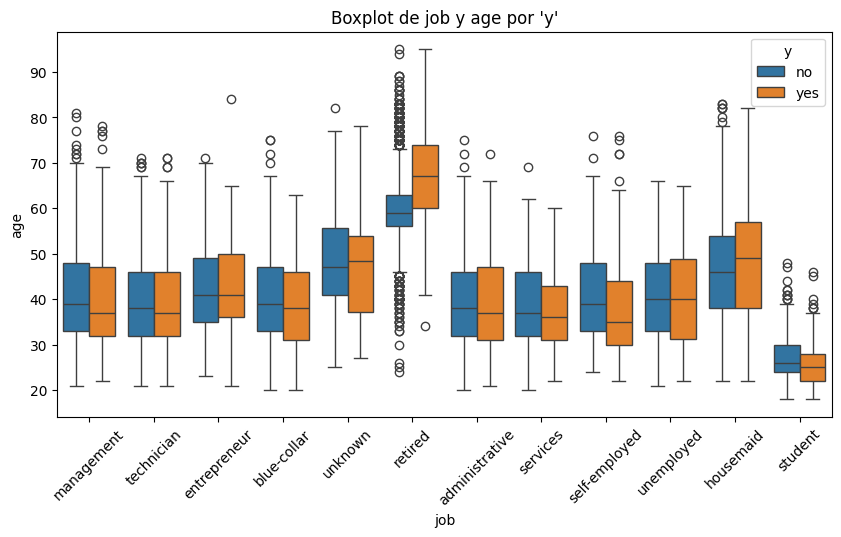

Relación de la columna categórica job y la columna numérica balance con la variable objetivo 'y'


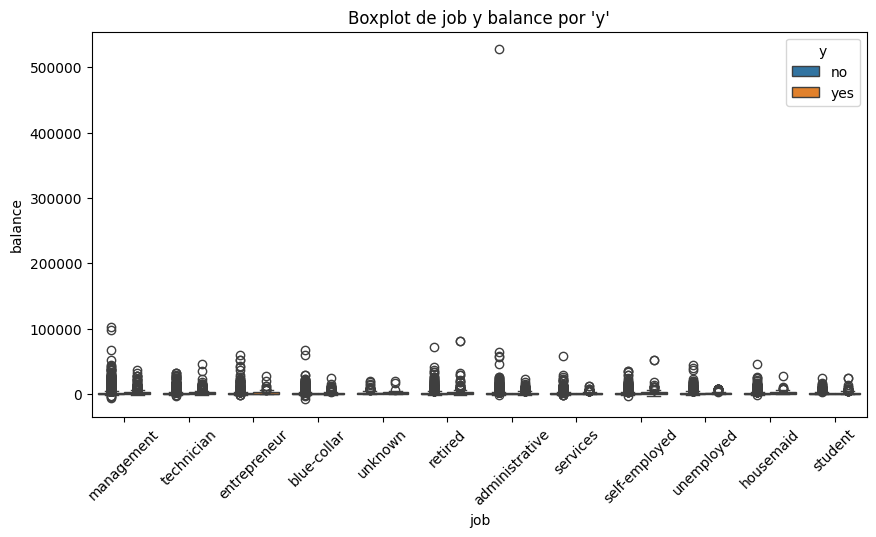

Relación de la columna categórica job y la columna numérica day con la variable objetivo 'y'


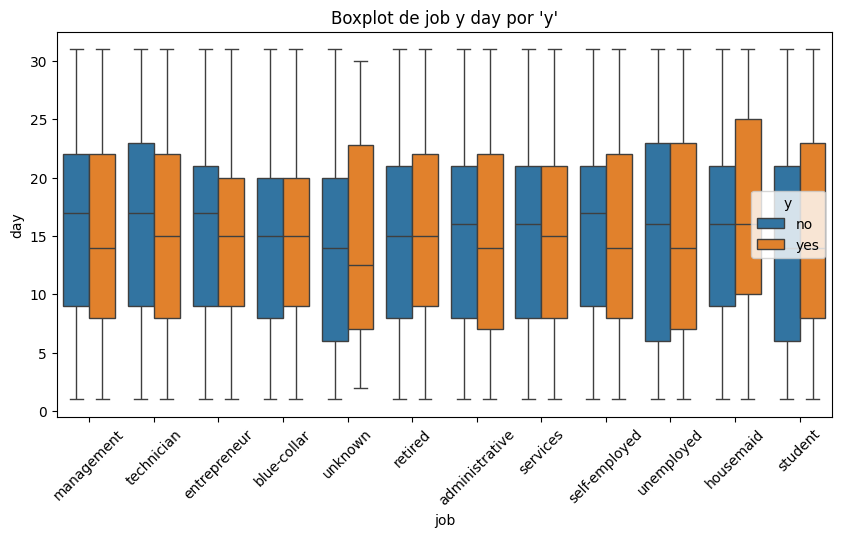

Relación de la columna categórica job y la columna numérica duration con la variable objetivo 'y'


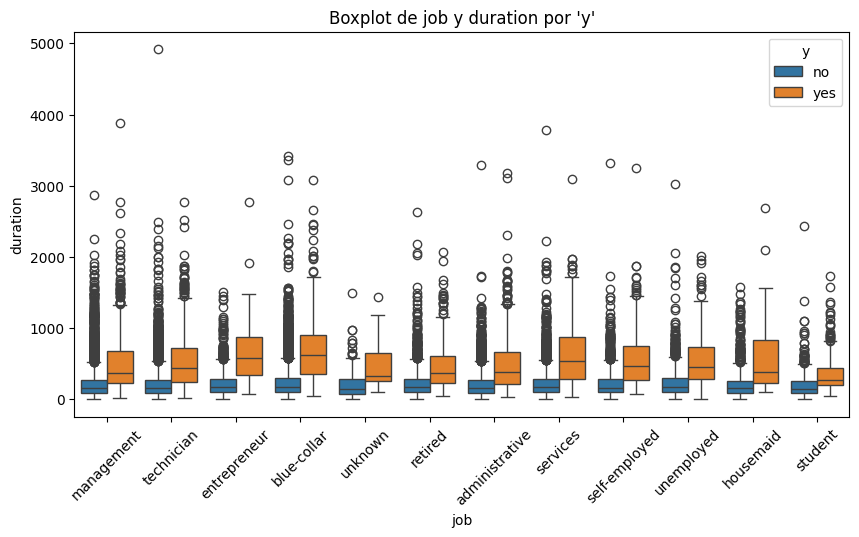

Relación de la columna categórica job y la columna numérica campaign con la variable objetivo 'y'


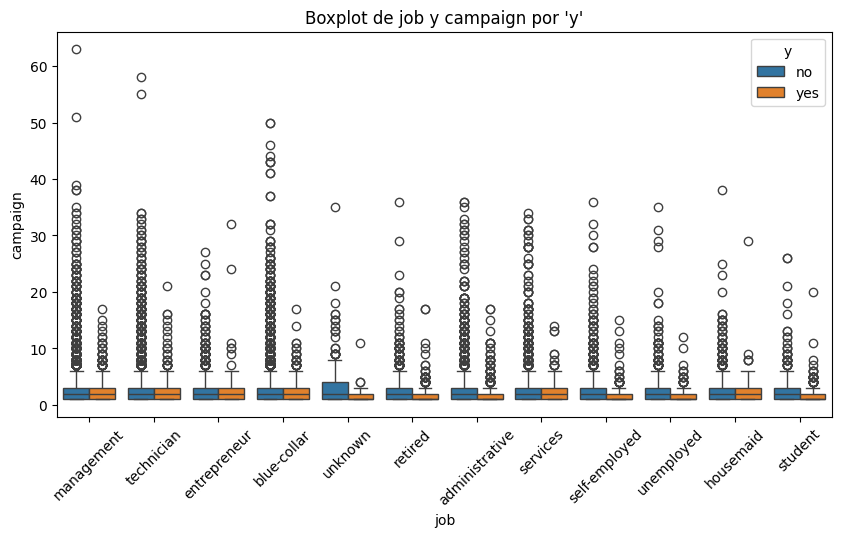

Relación de la columna categórica job y la columna numérica pdays con la variable objetivo 'y'


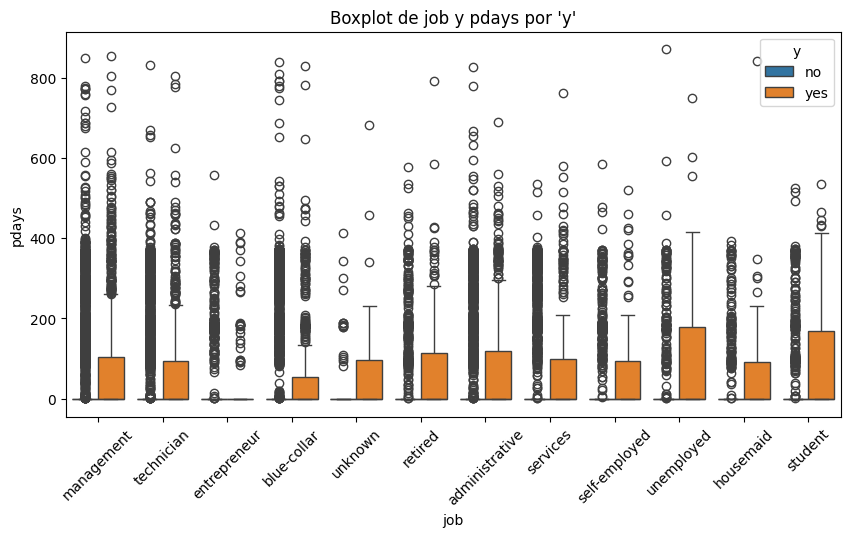

Relación de la columna categórica job y la columna numérica previous con la variable objetivo 'y'


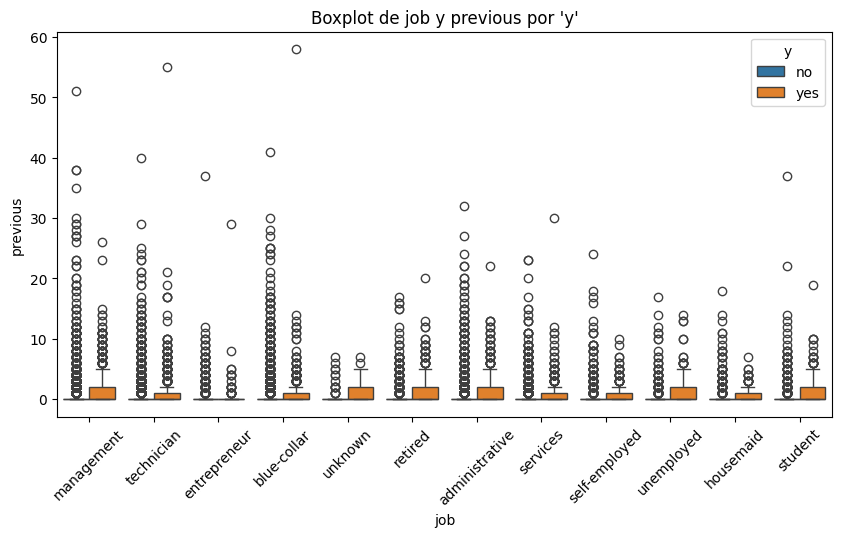

Relación de la columna categórica marital y la columna numérica age con la variable objetivo 'y'


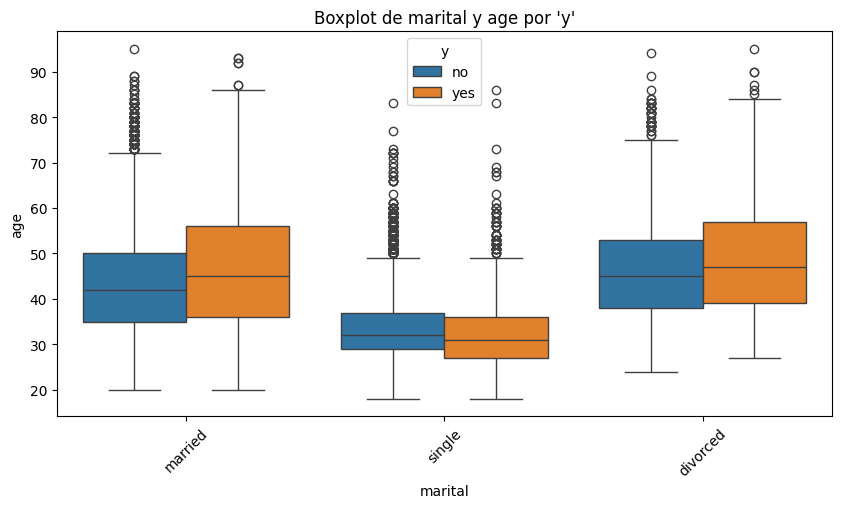

Relación de la columna categórica marital y la columna numérica balance con la variable objetivo 'y'


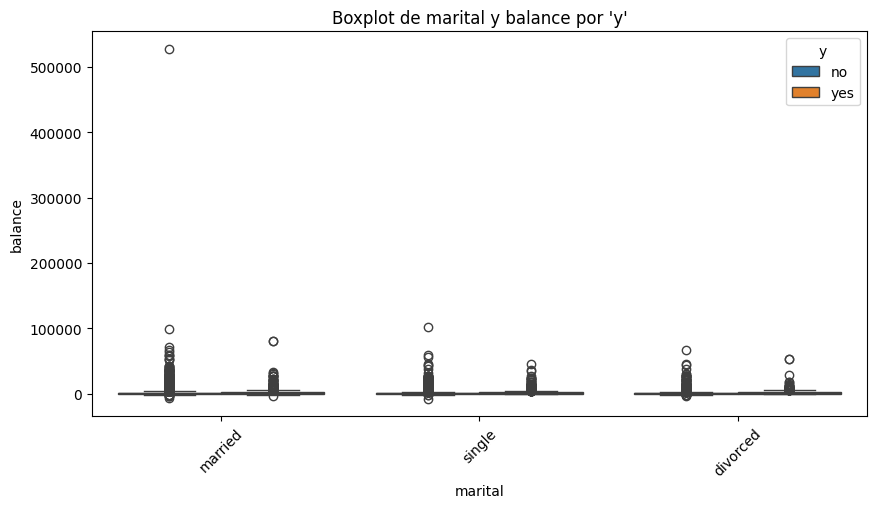

Relación de la columna categórica marital y la columna numérica day con la variable objetivo 'y'


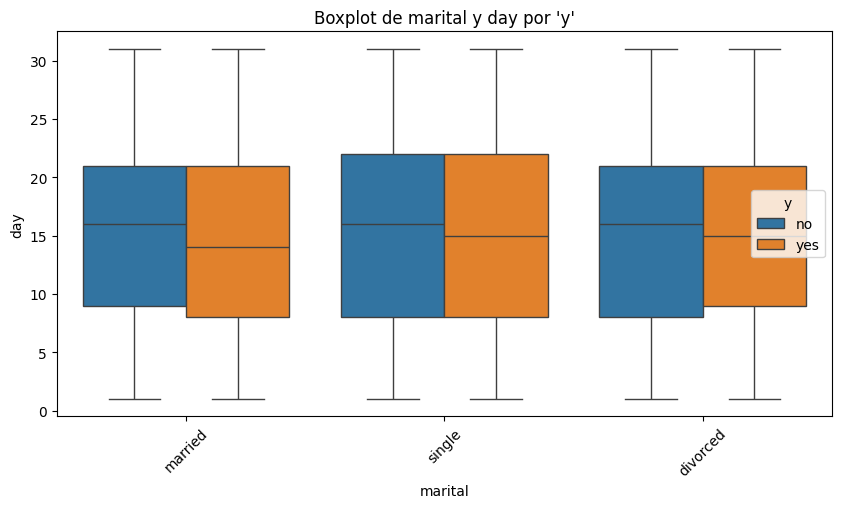

Relación de la columna categórica marital y la columna numérica duration con la variable objetivo 'y'


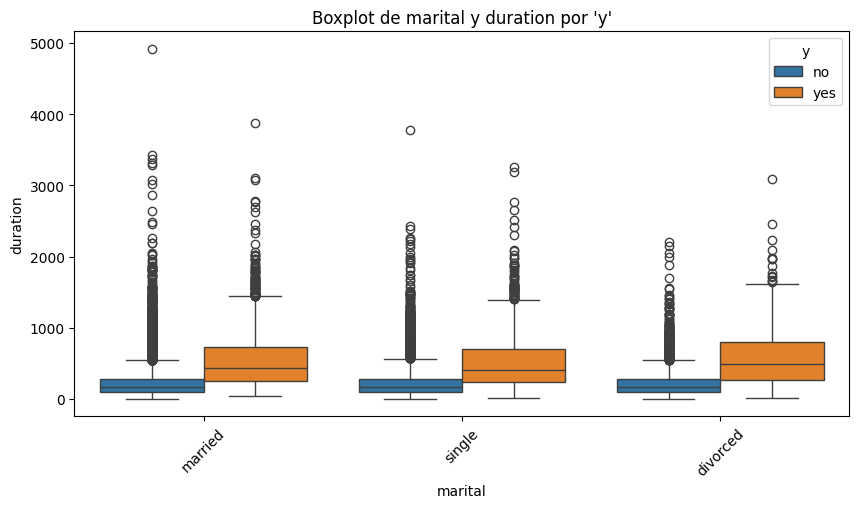

Relación de la columna categórica marital y la columna numérica campaign con la variable objetivo 'y'


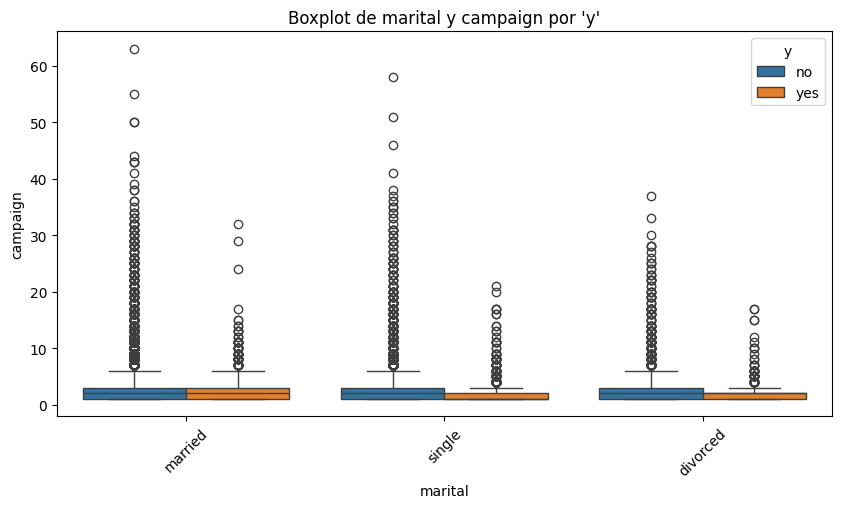

Relación de la columna categórica marital y la columna numérica pdays con la variable objetivo 'y'


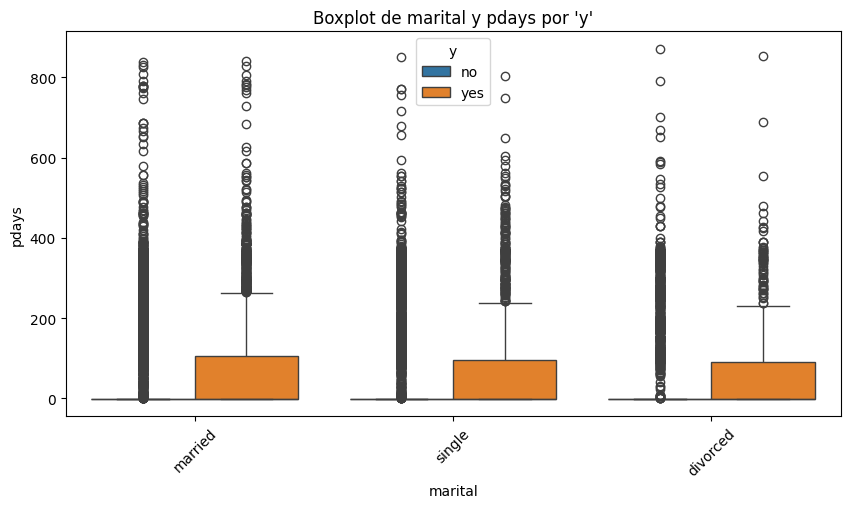

Relación de la columna categórica marital y la columna numérica previous con la variable objetivo 'y'


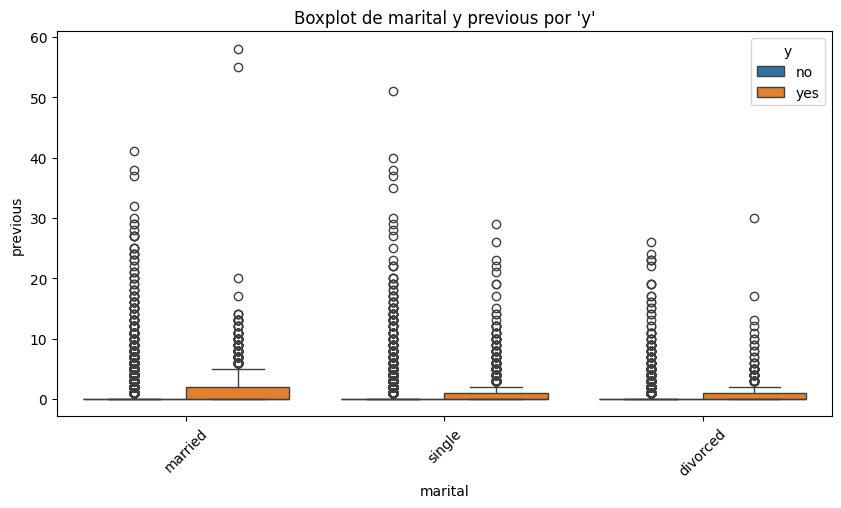

Relación de la columna categórica education y la columna numérica age con la variable objetivo 'y'


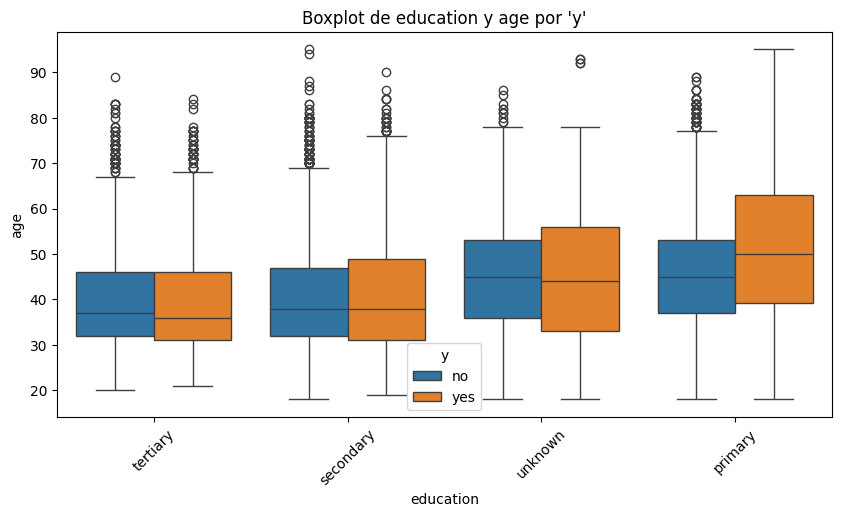

Relación de la columna categórica education y la columna numérica balance con la variable objetivo 'y'


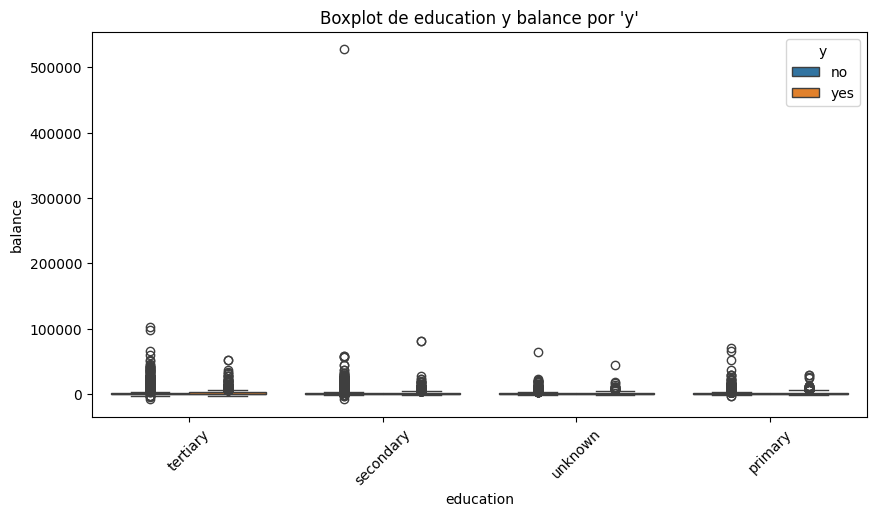

Relación de la columna categórica education y la columna numérica day con la variable objetivo 'y'


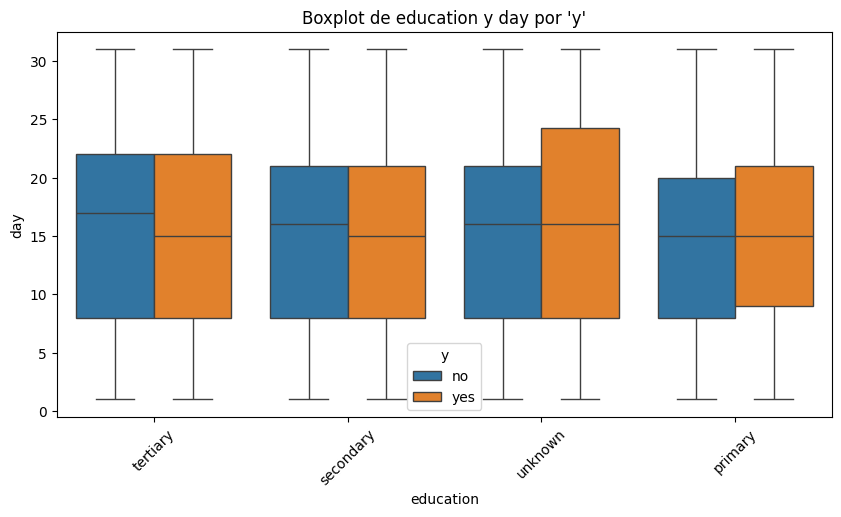

Relación de la columna categórica education y la columna numérica duration con la variable objetivo 'y'


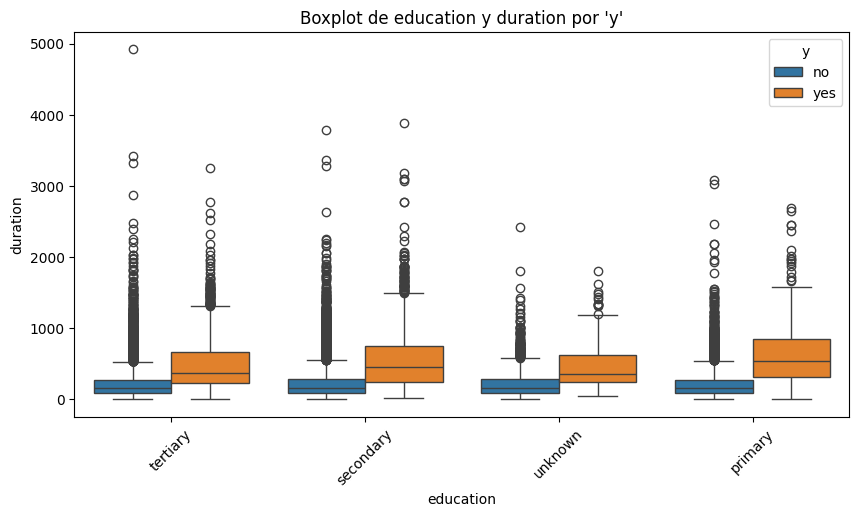

Relación de la columna categórica education y la columna numérica campaign con la variable objetivo 'y'


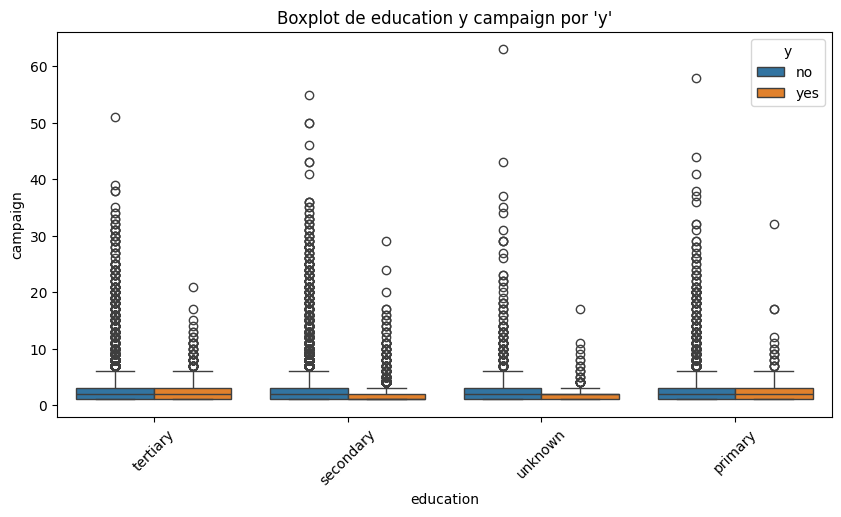

Relación de la columna categórica education y la columna numérica pdays con la variable objetivo 'y'


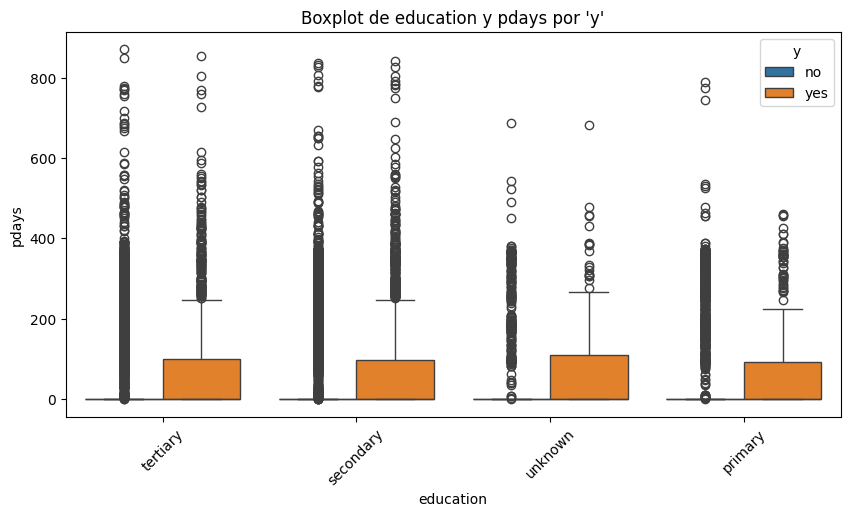

Relación de la columna categórica education y la columna numérica previous con la variable objetivo 'y'


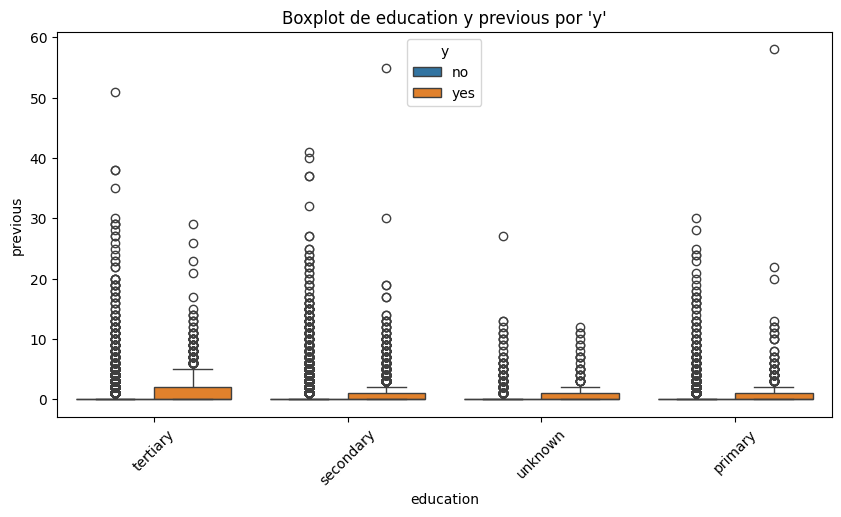

Relación de la columna categórica default y la columna numérica age con la variable objetivo 'y'


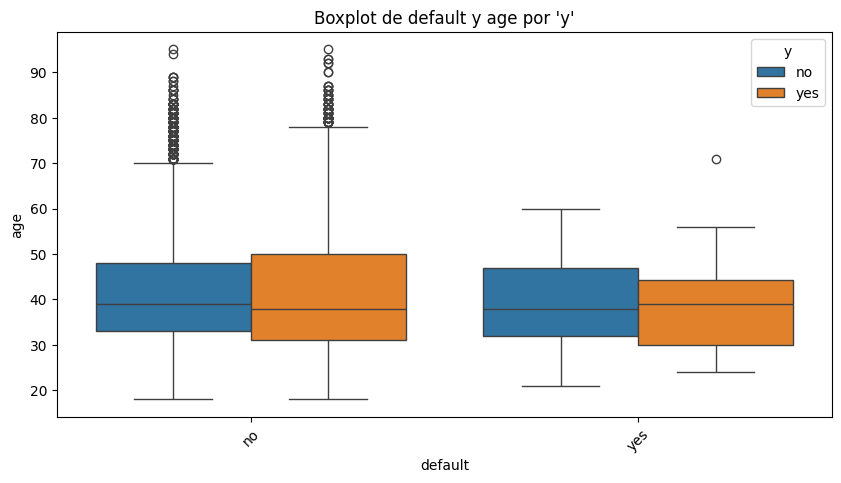

Relación de la columna categórica default y la columna numérica balance con la variable objetivo 'y'


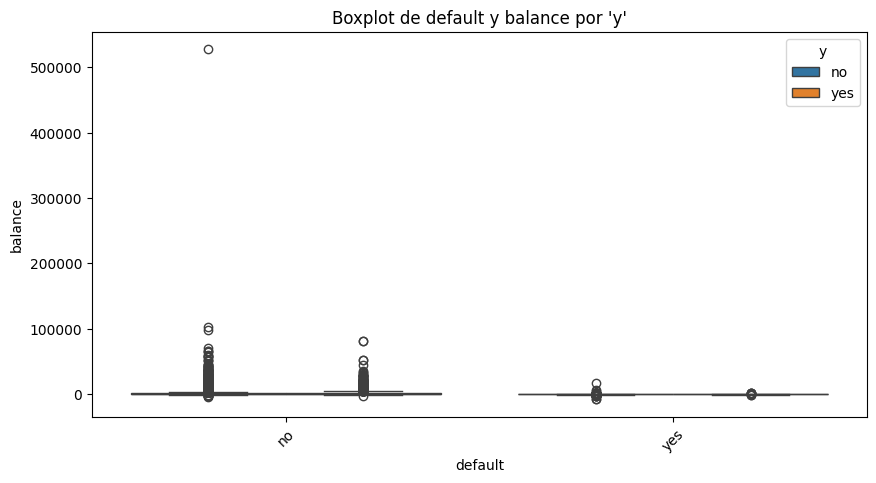

Relación de la columna categórica default y la columna numérica day con la variable objetivo 'y'


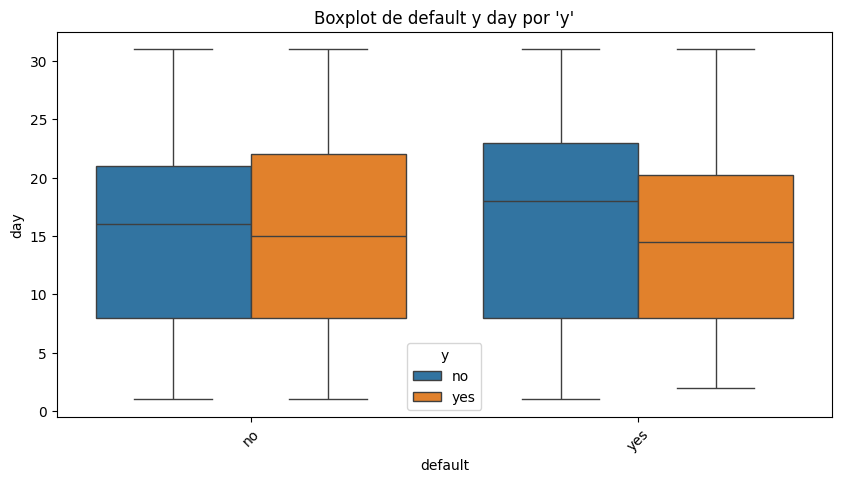

Relación de la columna categórica default y la columna numérica duration con la variable objetivo 'y'


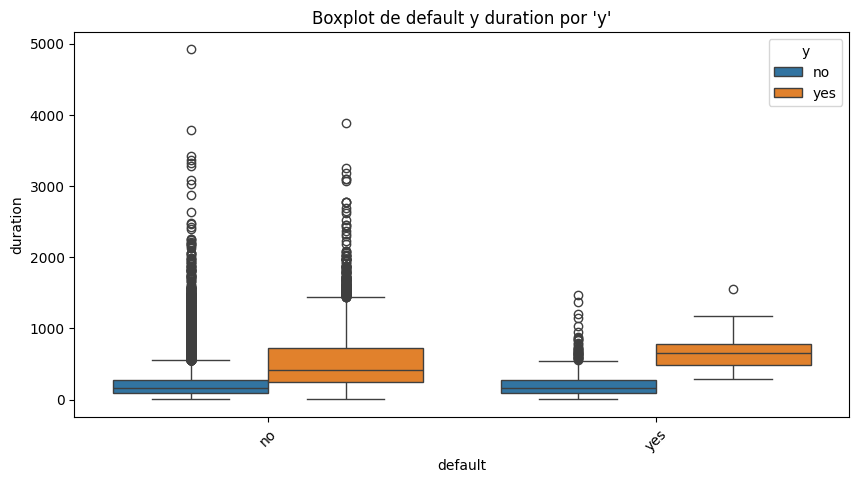

Relación de la columna categórica default y la columna numérica campaign con la variable objetivo 'y'


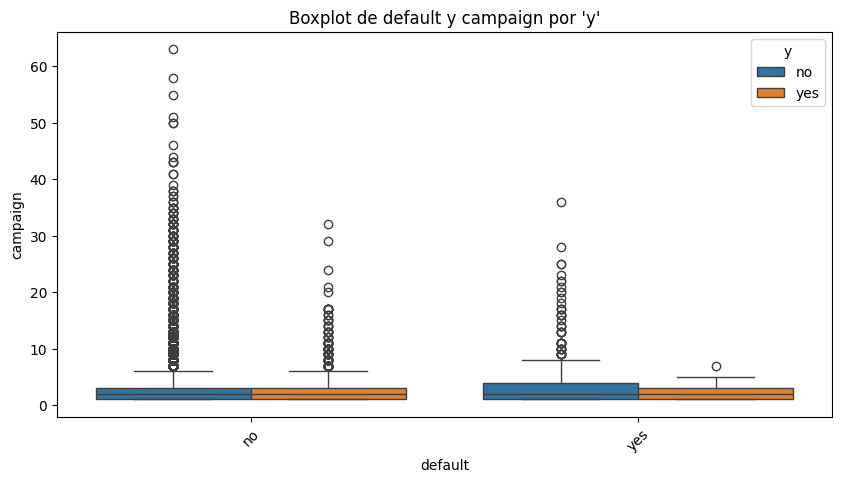

Relación de la columna categórica default y la columna numérica pdays con la variable objetivo 'y'


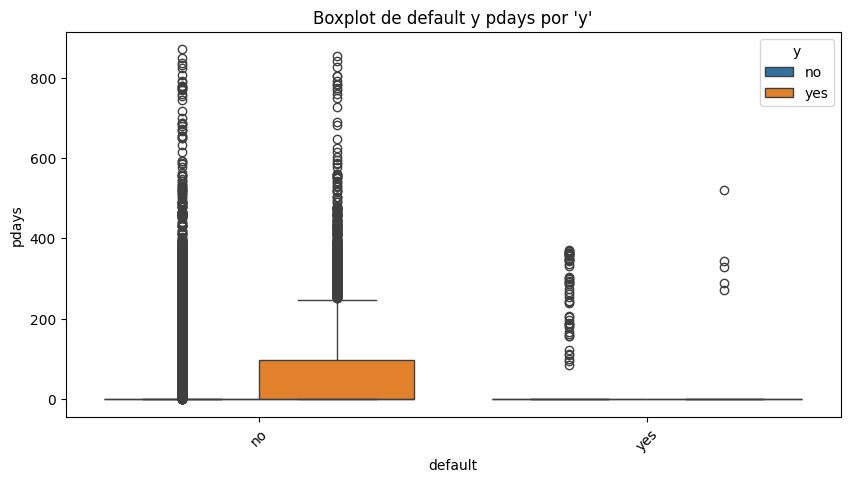

Relación de la columna categórica default y la columna numérica previous con la variable objetivo 'y'


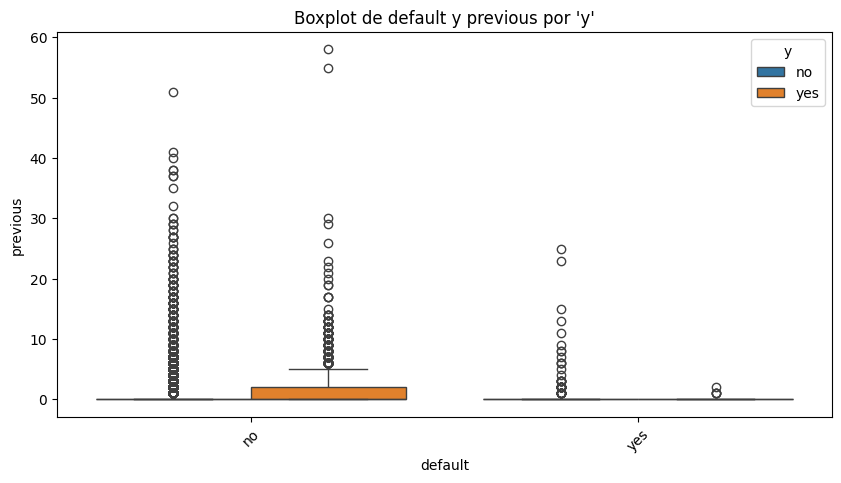

Relación de la columna categórica housing y la columna numérica age con la variable objetivo 'y'


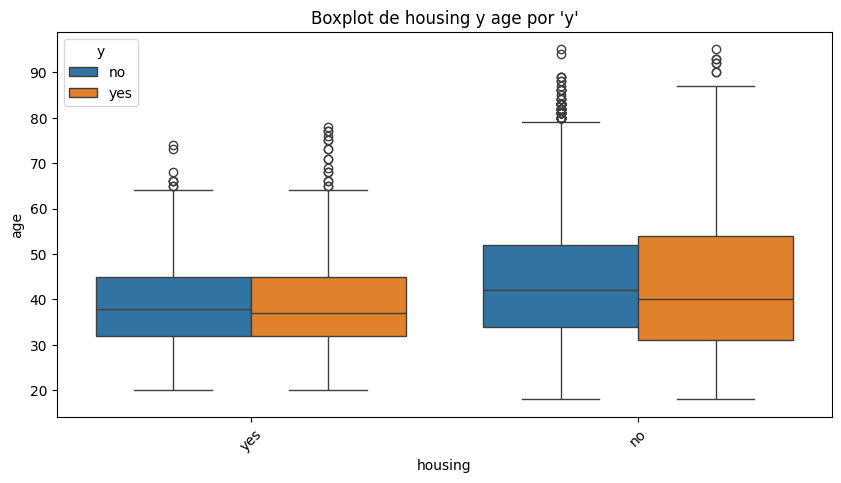

Relación de la columna categórica housing y la columna numérica balance con la variable objetivo 'y'


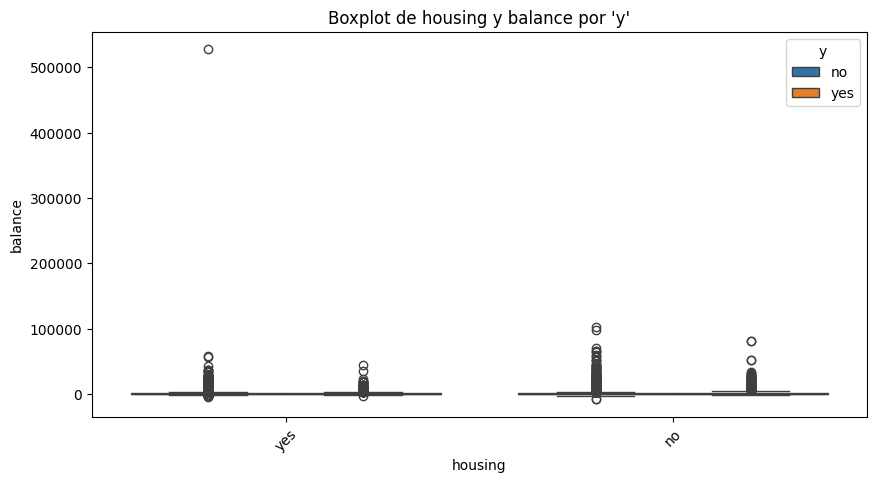

Relación de la columna categórica housing y la columna numérica day con la variable objetivo 'y'


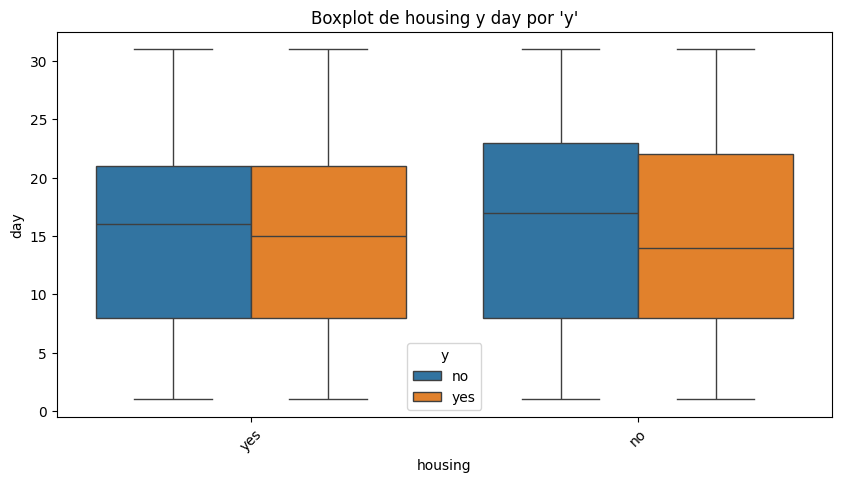

Relación de la columna categórica housing y la columna numérica duration con la variable objetivo 'y'


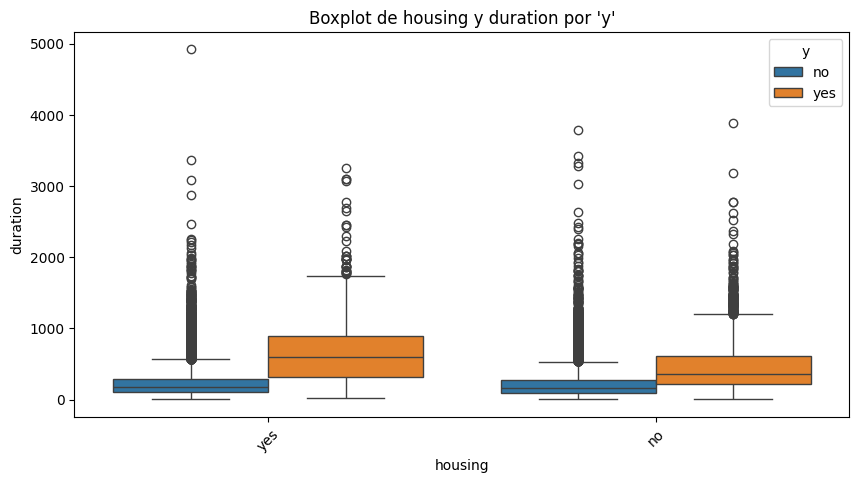

Relación de la columna categórica housing y la columna numérica campaign con la variable objetivo 'y'


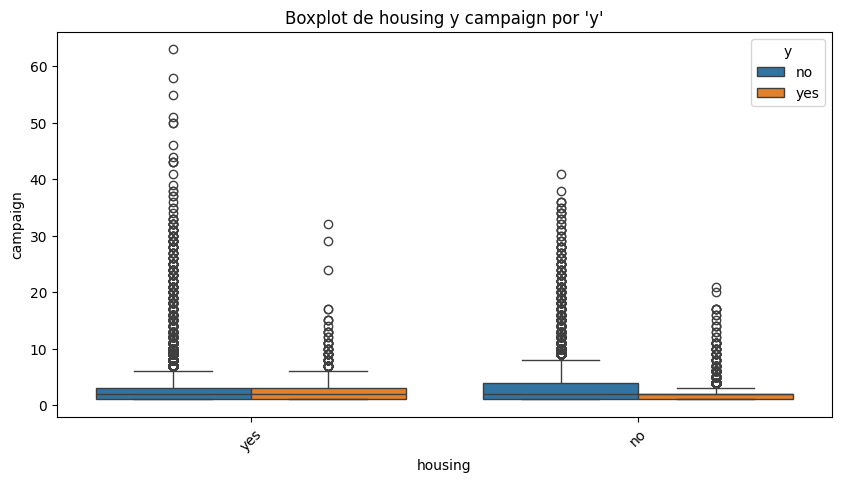

Relación de la columna categórica housing y la columna numérica pdays con la variable objetivo 'y'


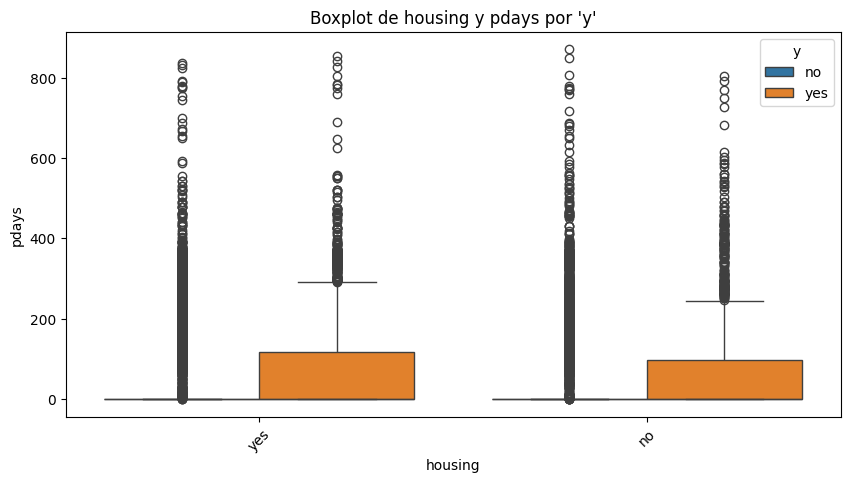

Relación de la columna categórica housing y la columna numérica previous con la variable objetivo 'y'


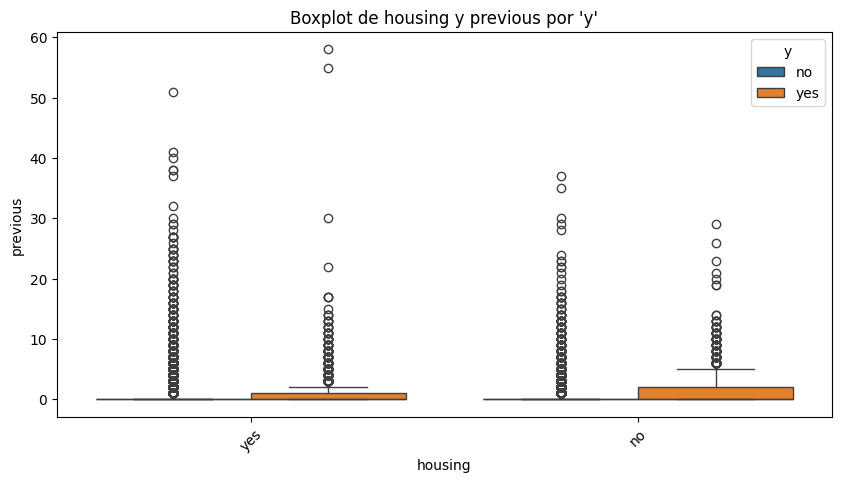

Relación de la columna categórica loan y la columna numérica age con la variable objetivo 'y'


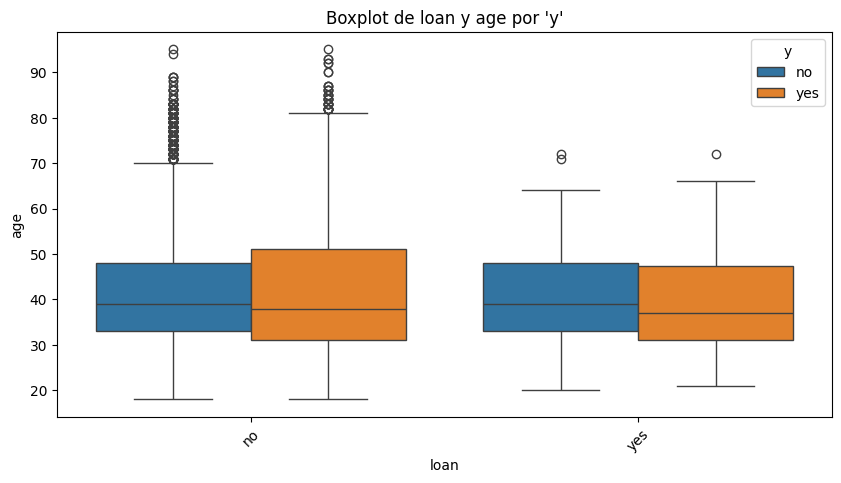

Relación de la columna categórica loan y la columna numérica balance con la variable objetivo 'y'


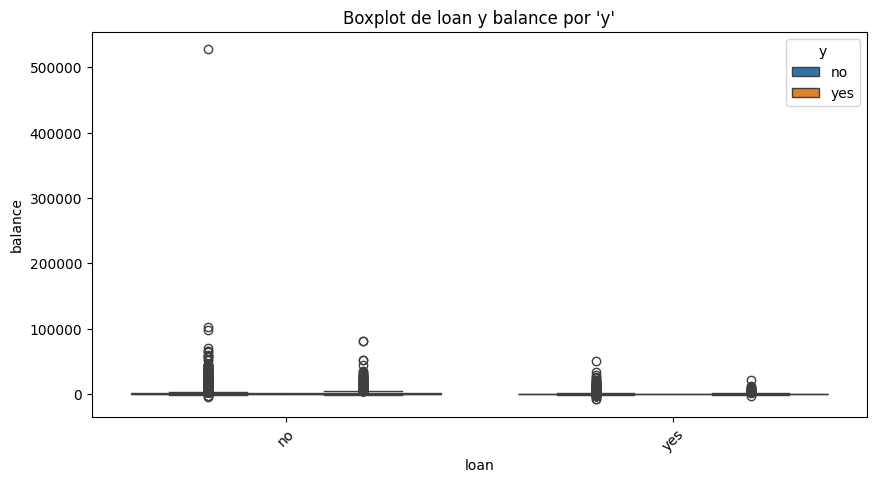

Relación de la columna categórica loan y la columna numérica day con la variable objetivo 'y'


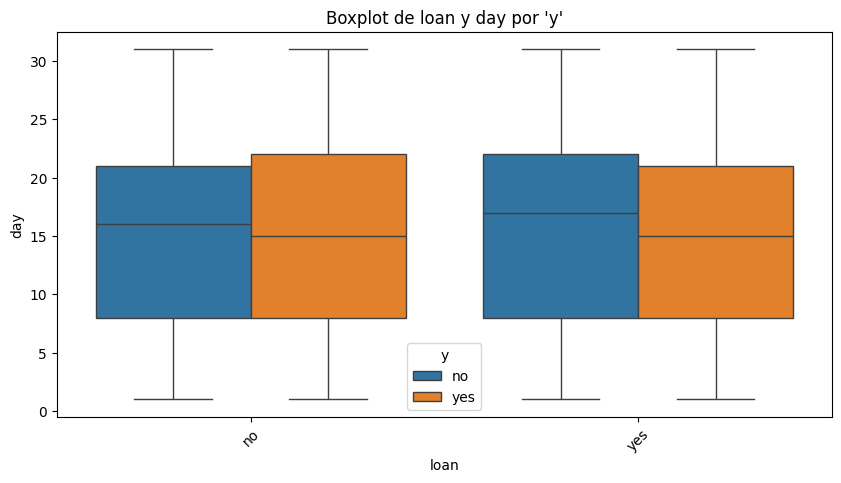

Relación de la columna categórica loan y la columna numérica duration con la variable objetivo 'y'


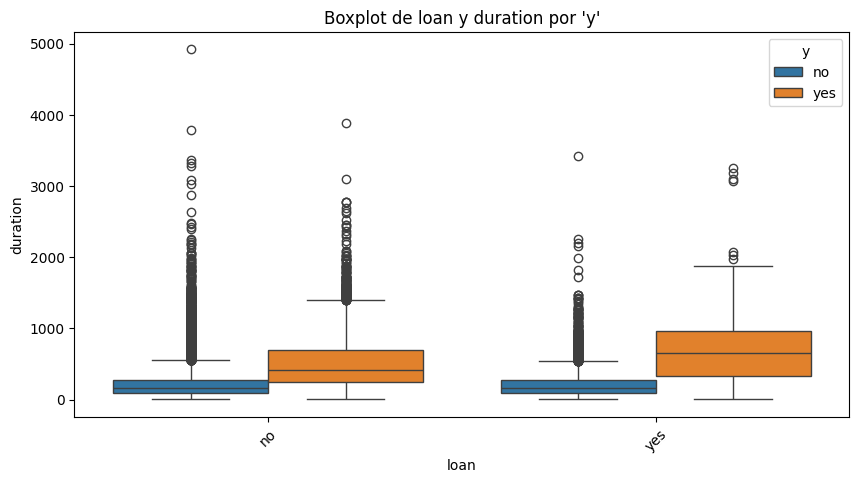

Relación de la columna categórica loan y la columna numérica campaign con la variable objetivo 'y'


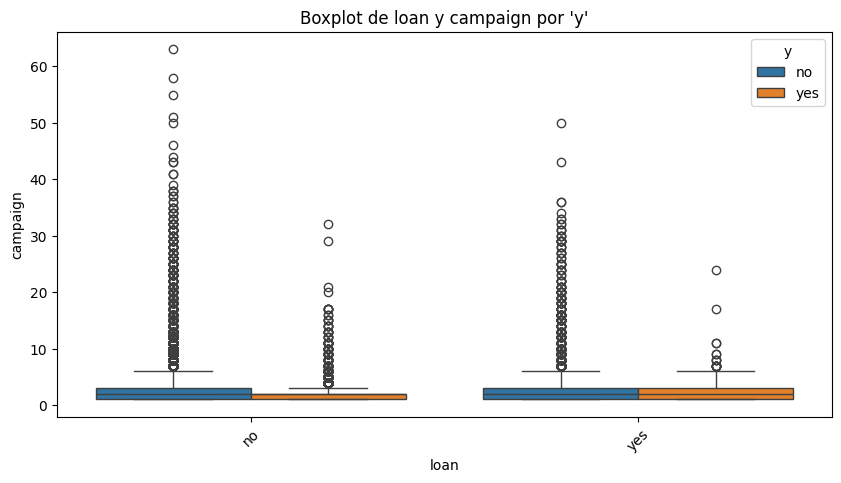

Relación de la columna categórica loan y la columna numérica pdays con la variable objetivo 'y'


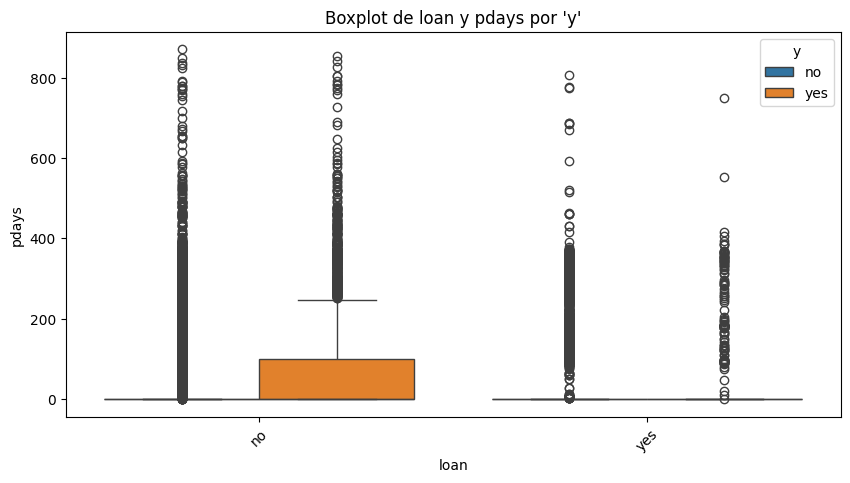

Relación de la columna categórica loan y la columna numérica previous con la variable objetivo 'y'


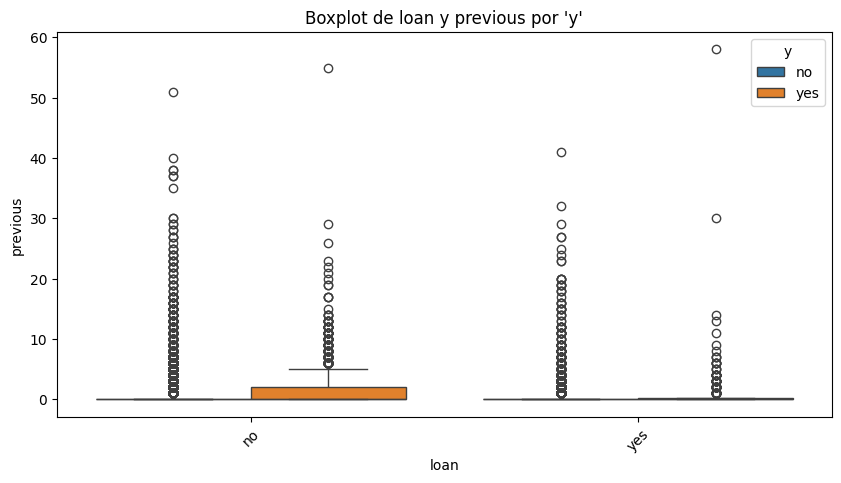

Relación de la columna categórica contact y la columna numérica age con la variable objetivo 'y'


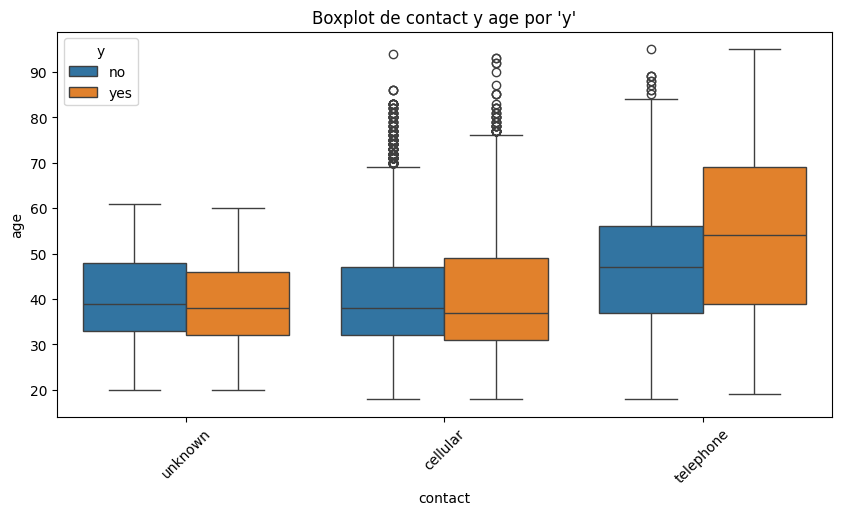

Relación de la columna categórica contact y la columna numérica balance con la variable objetivo 'y'


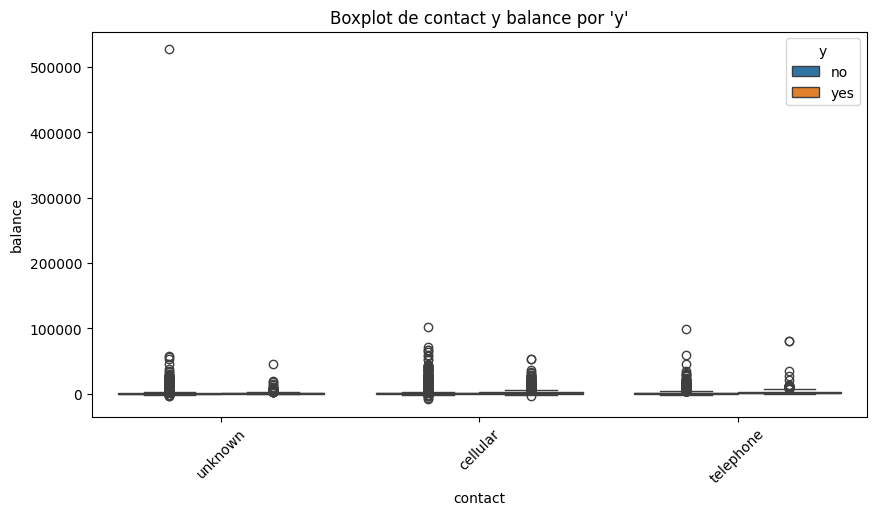

Relación de la columna categórica contact y la columna numérica day con la variable objetivo 'y'


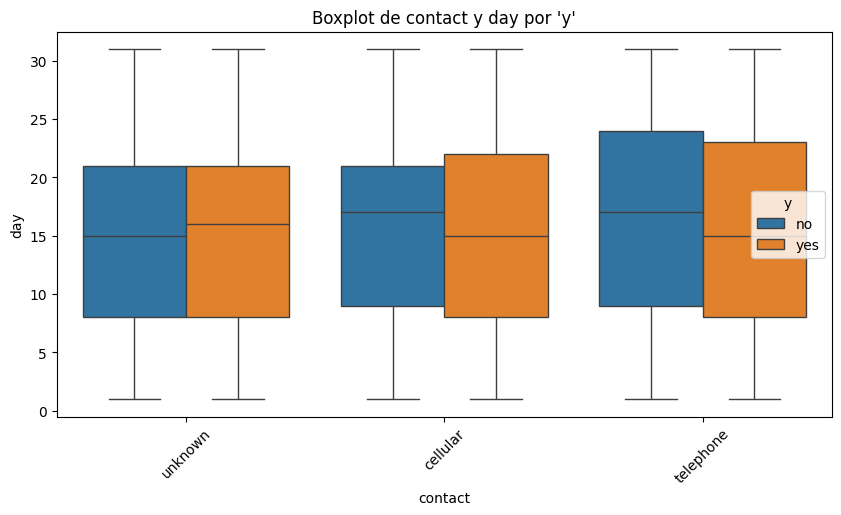

Relación de la columna categórica contact y la columna numérica duration con la variable objetivo 'y'


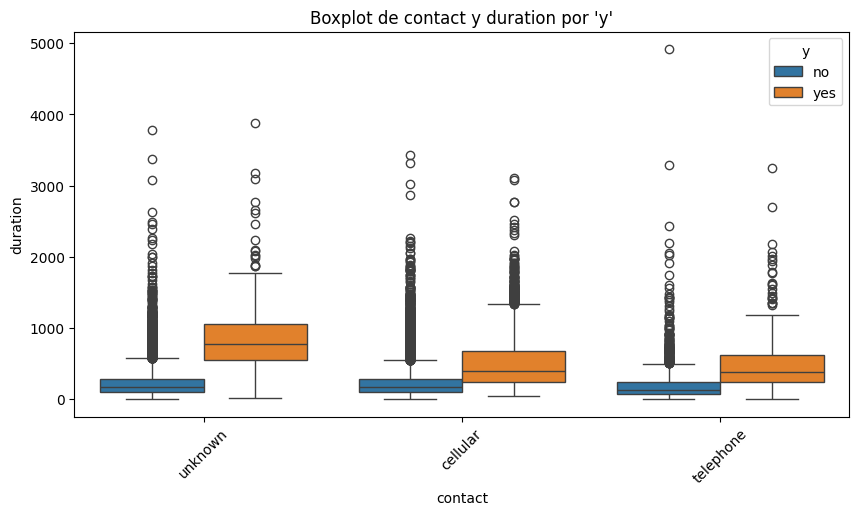

Relación de la columna categórica contact y la columna numérica campaign con la variable objetivo 'y'


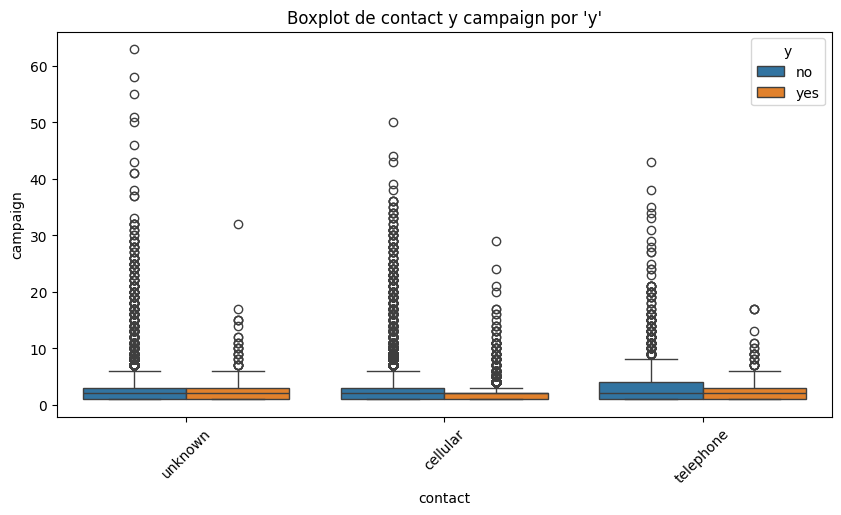

Relación de la columna categórica contact y la columna numérica pdays con la variable objetivo 'y'


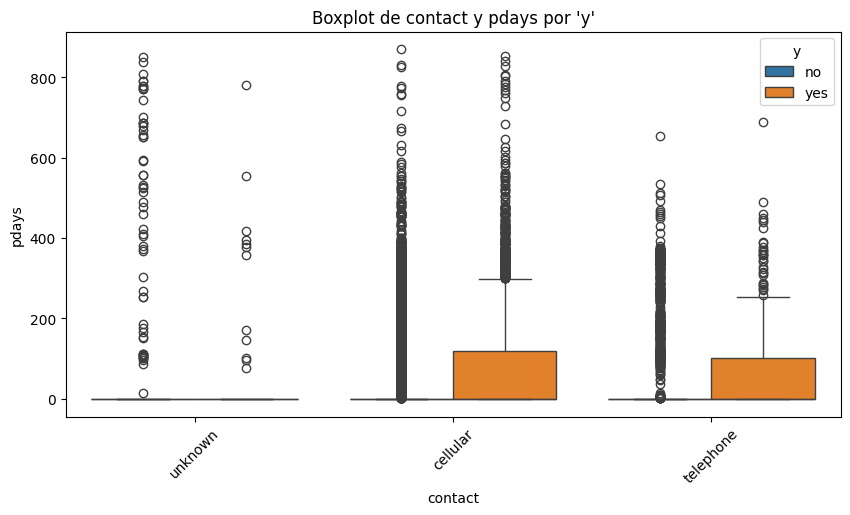

Relación de la columna categórica contact y la columna numérica previous con la variable objetivo 'y'


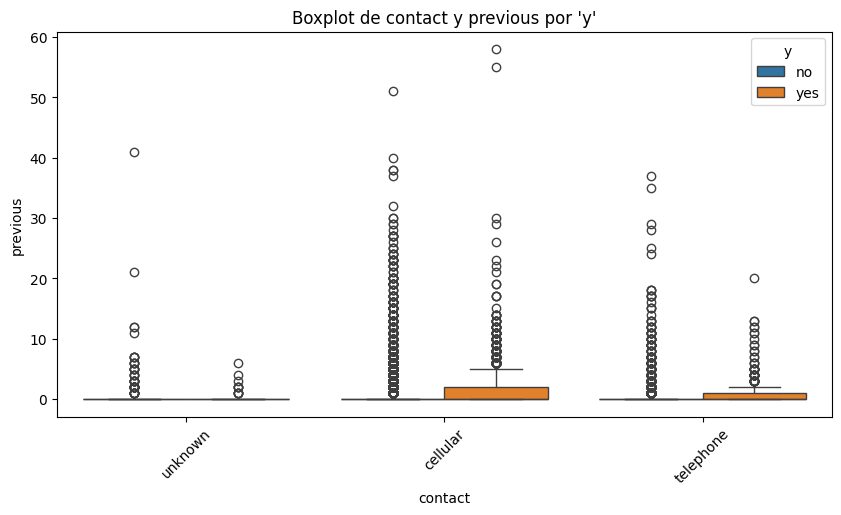

Relación de la columna categórica month y la columna numérica age con la variable objetivo 'y'


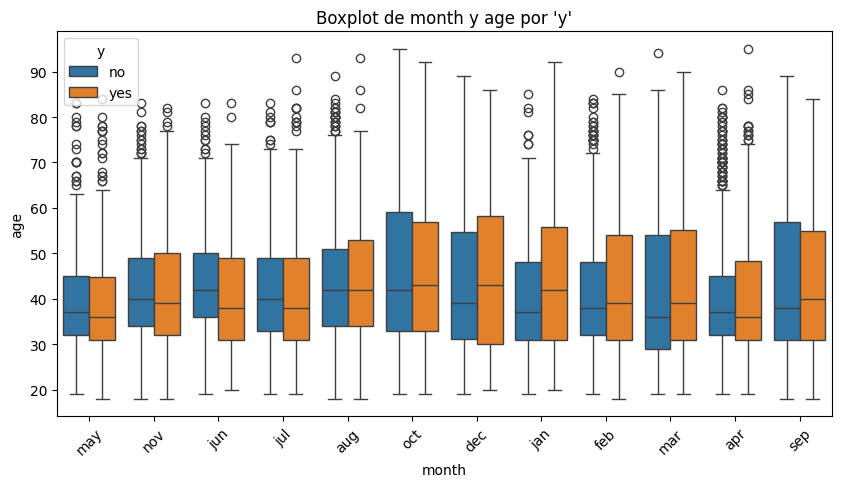

Relación de la columna categórica month y la columna numérica balance con la variable objetivo 'y'


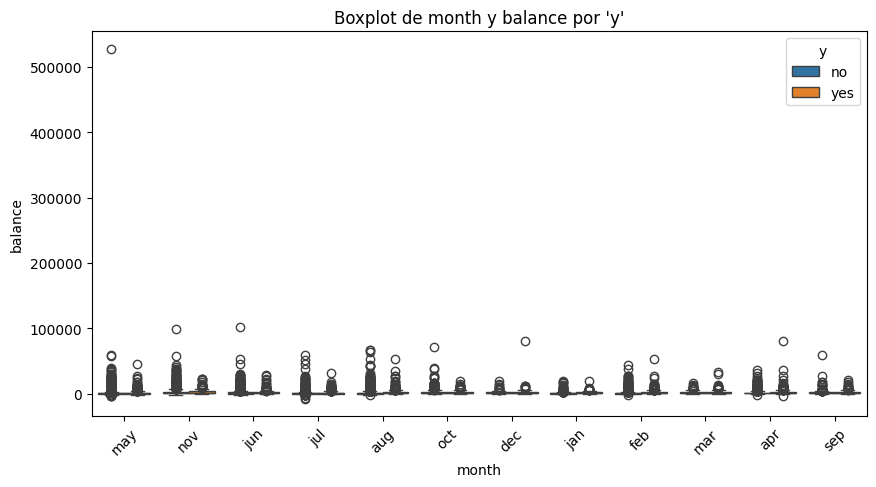

Relación de la columna categórica month y la columna numérica day con la variable objetivo 'y'


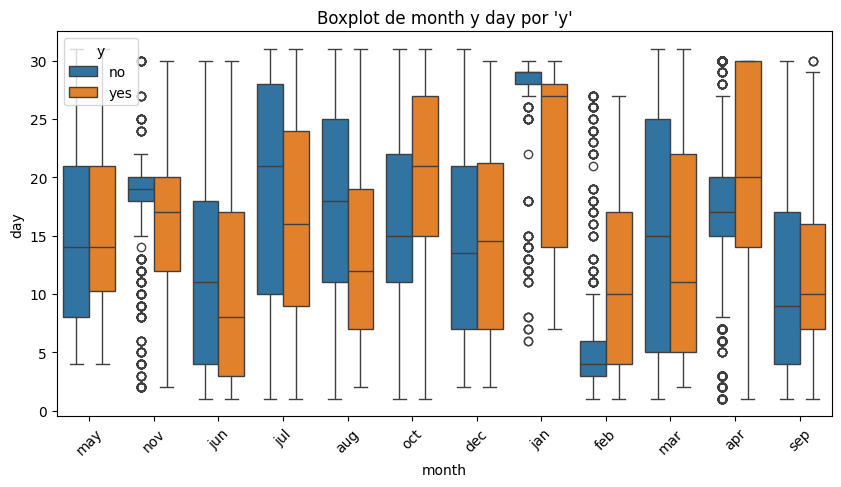

Relación de la columna categórica month y la columna numérica duration con la variable objetivo 'y'


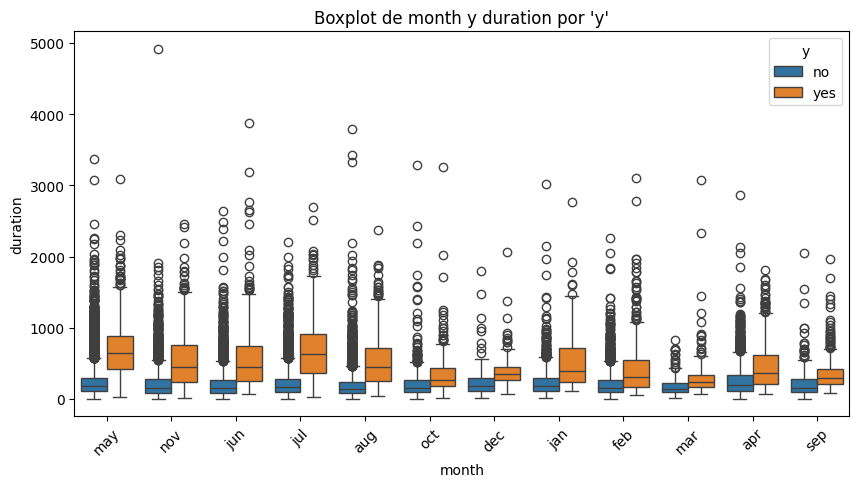

Relación de la columna categórica month y la columna numérica campaign con la variable objetivo 'y'


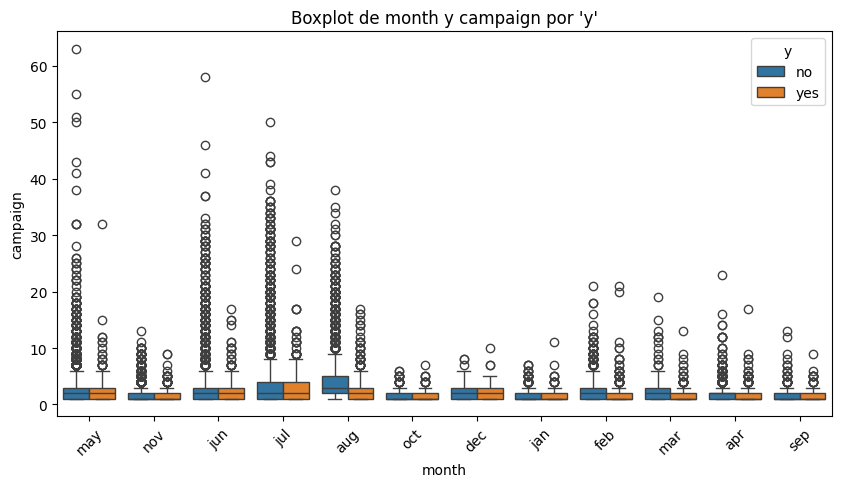

Relación de la columna categórica month y la columna numérica pdays con la variable objetivo 'y'


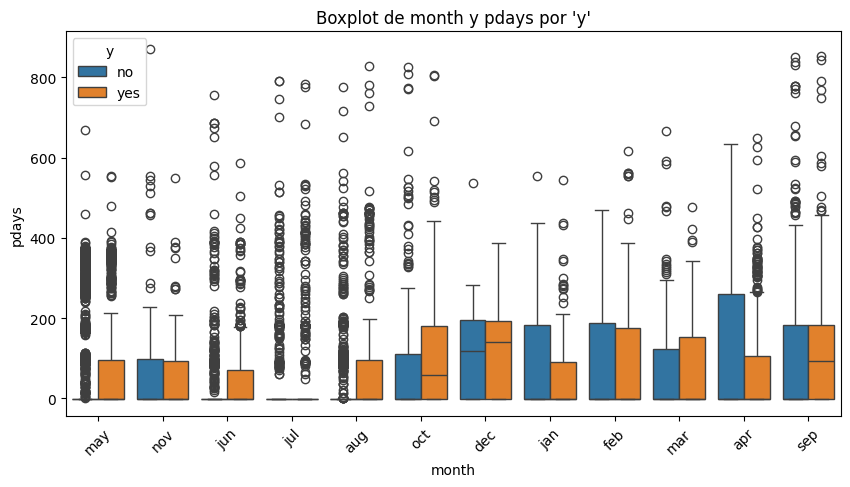

Relación de la columna categórica month y la columna numérica previous con la variable objetivo 'y'


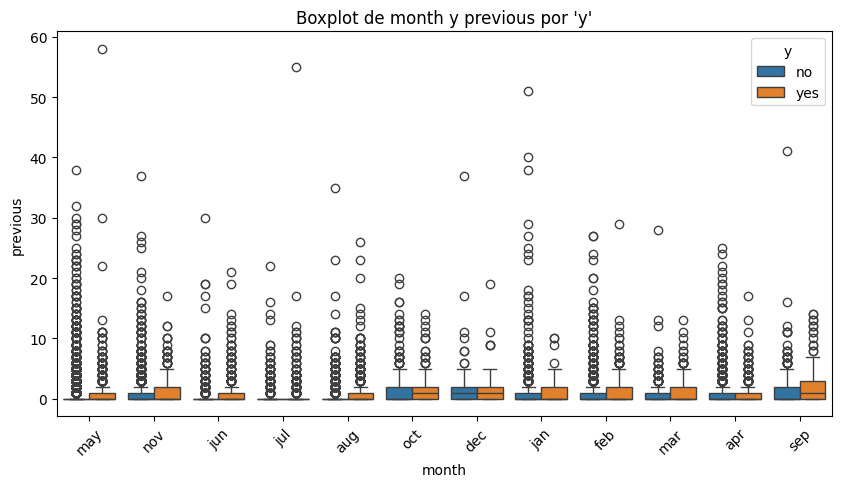

Relación de la columna categórica poutcome y la columna numérica age con la variable objetivo 'y'


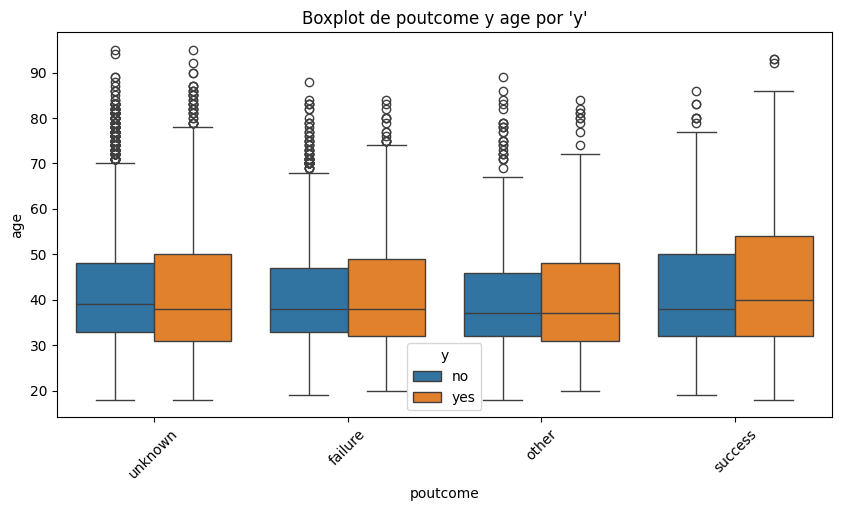

Relación de la columna categórica poutcome y la columna numérica balance con la variable objetivo 'y'


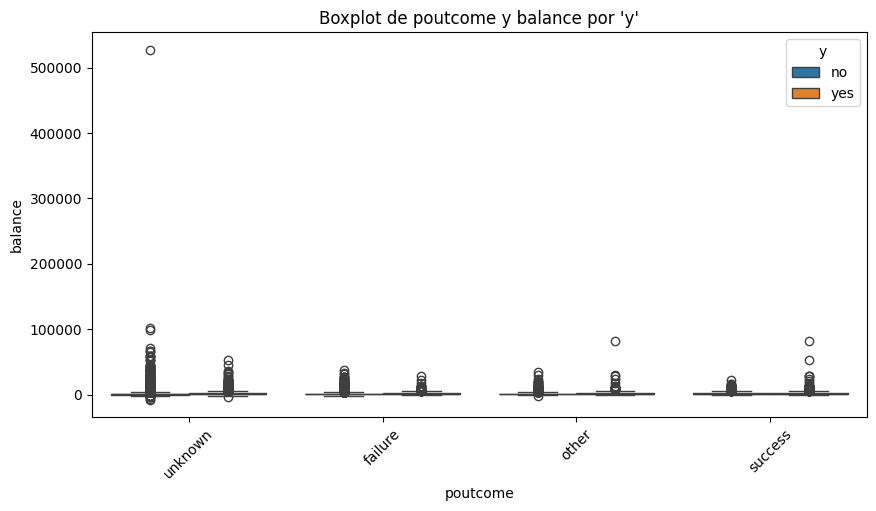

Relación de la columna categórica poutcome y la columna numérica day con la variable objetivo 'y'


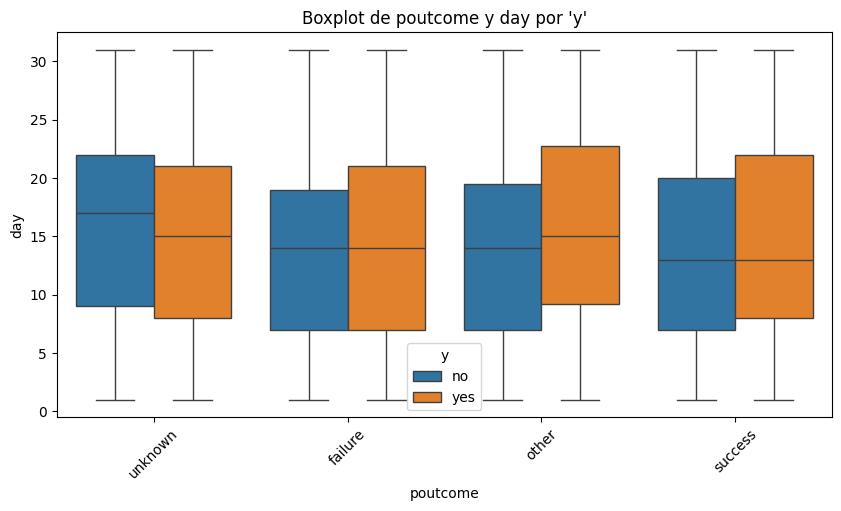

Relación de la columna categórica poutcome y la columna numérica duration con la variable objetivo 'y'


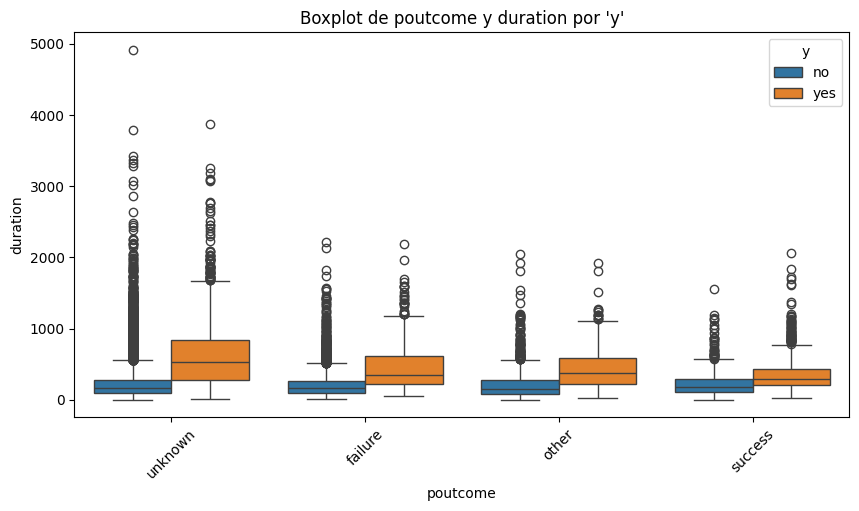

Relación de la columna categórica poutcome y la columna numérica campaign con la variable objetivo 'y'


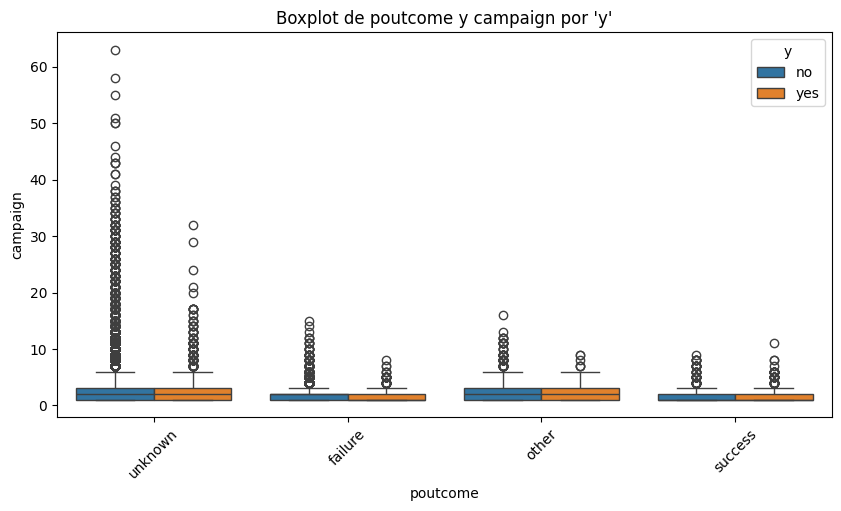

Relación de la columna categórica poutcome y la columna numérica pdays con la variable objetivo 'y'


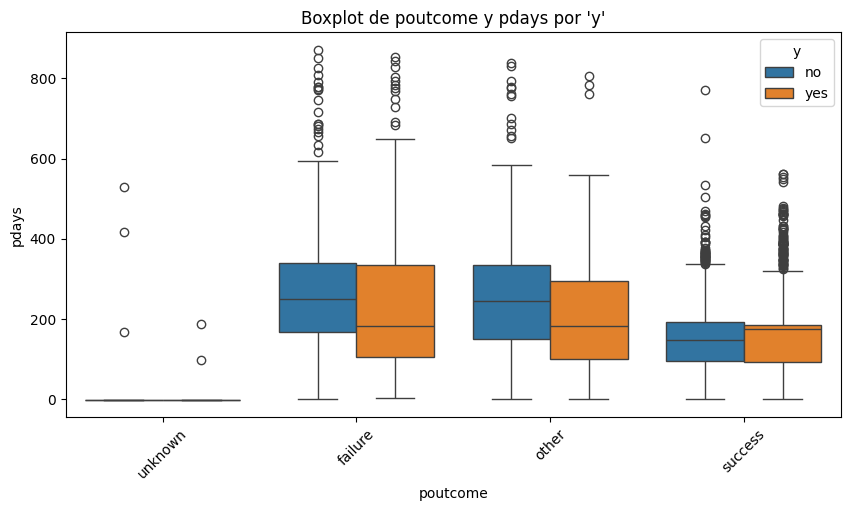

Relación de la columna categórica poutcome y la columna numérica previous con la variable objetivo 'y'


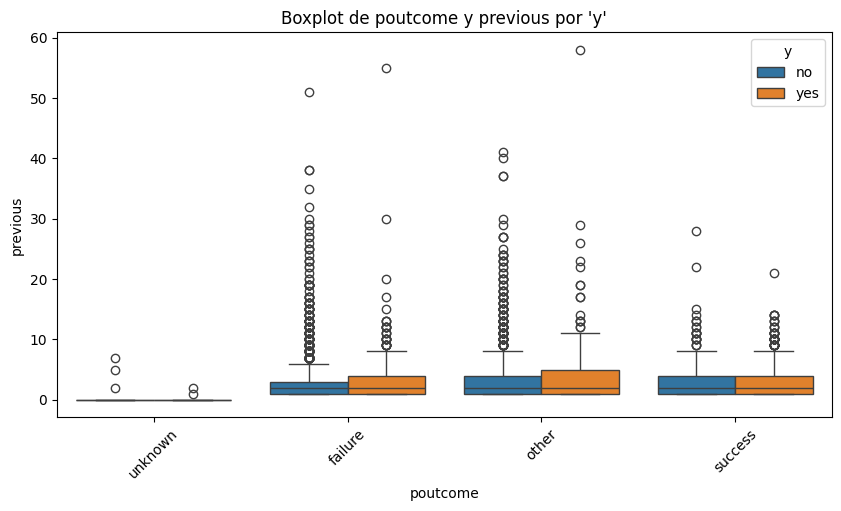

Relación de la columna categórica y y la columna numérica age con la variable objetivo 'y'


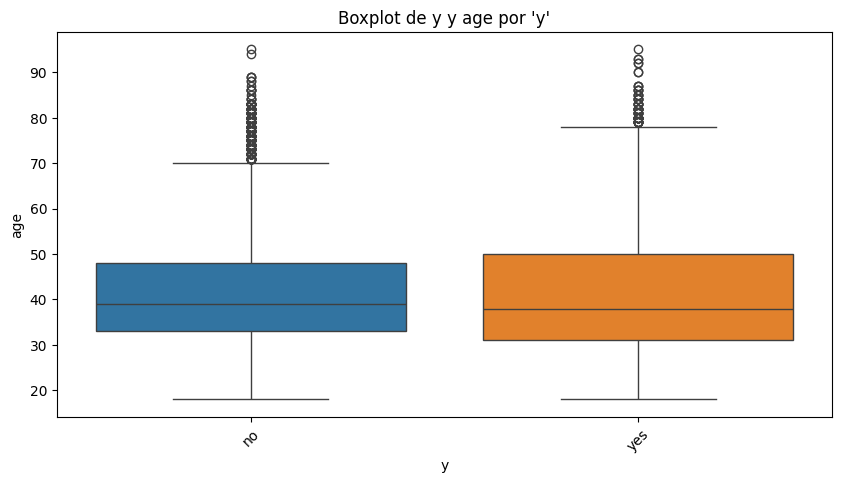

Relación de la columna categórica y y la columna numérica balance con la variable objetivo 'y'


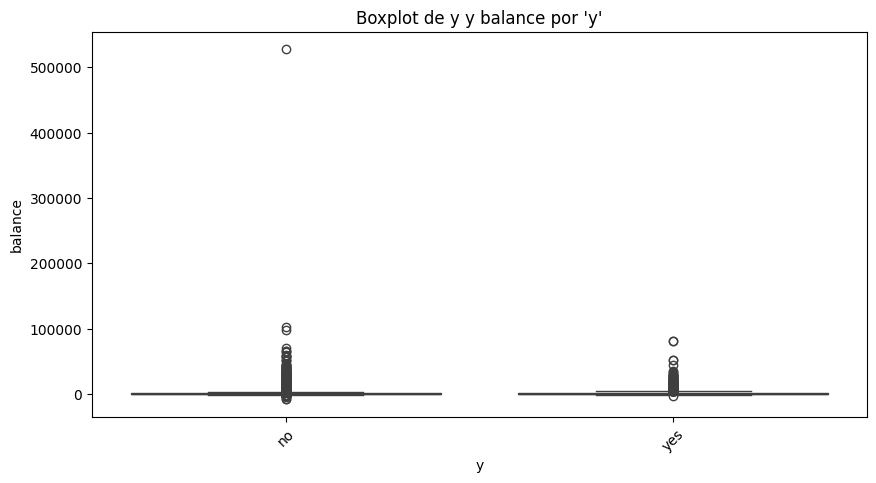

Relación de la columna categórica y y la columna numérica day con la variable objetivo 'y'


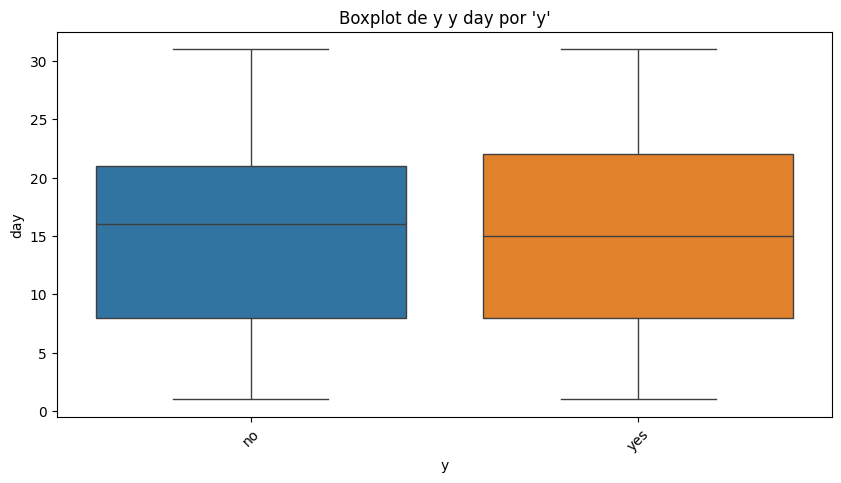

Relación de la columna categórica y y la columna numérica duration con la variable objetivo 'y'


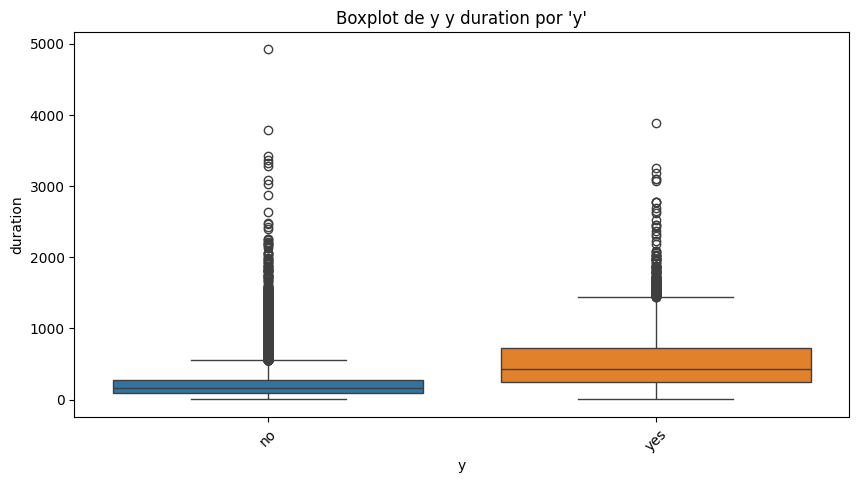

Relación de la columna categórica y y la columna numérica campaign con la variable objetivo 'y'


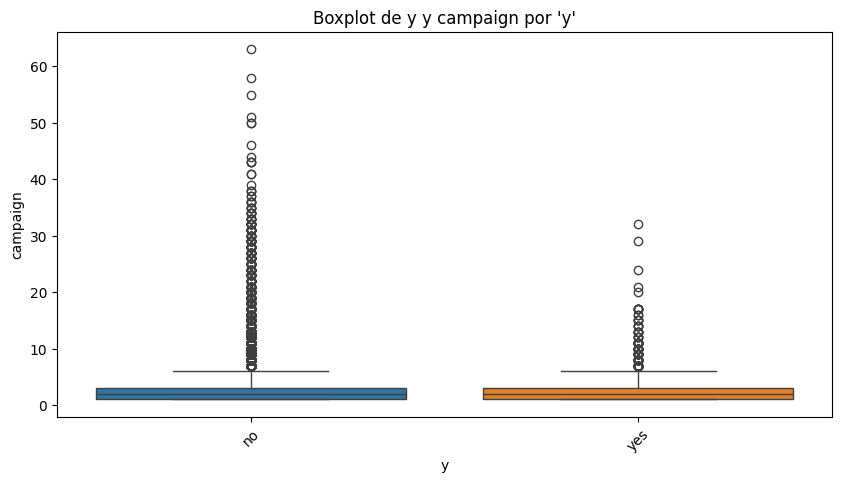

Relación de la columna categórica y y la columna numérica pdays con la variable objetivo 'y'


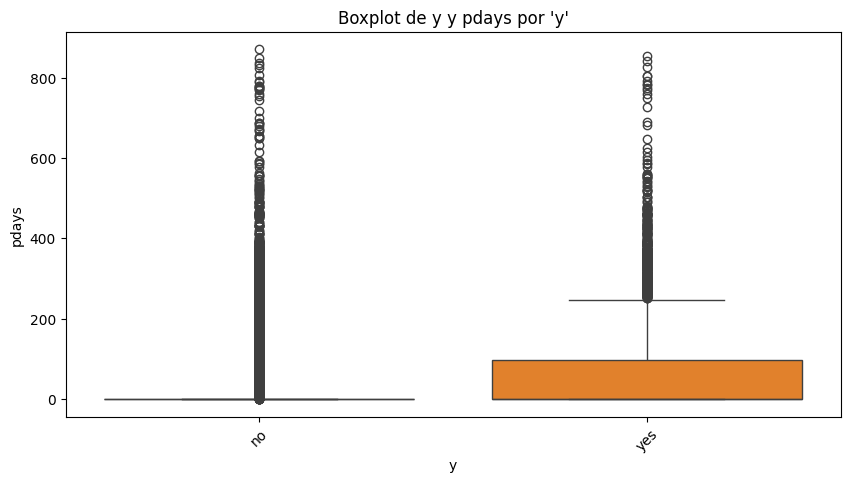

Relación de la columna categórica y y la columna numérica previous con la variable objetivo 'y'


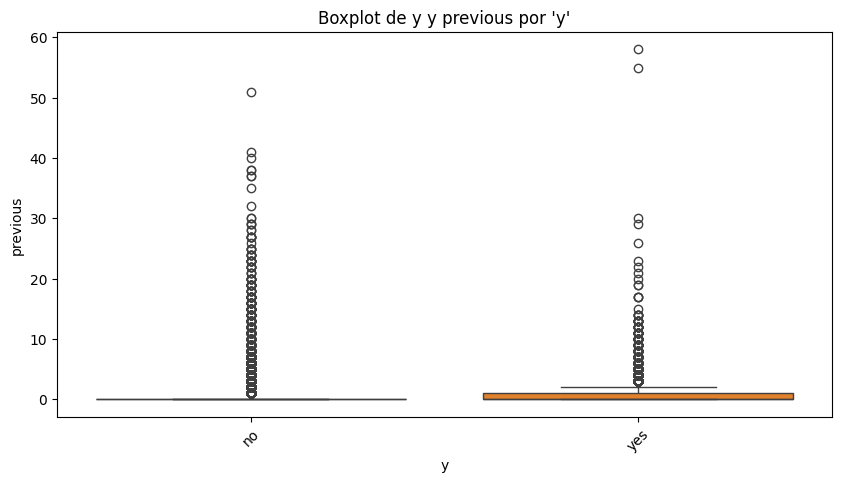

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Seleccionar columnas categóricas y numéricas
columnas_categoricas = data.select_dtypes(include=['object']).columns
columnas_numericas = data.select_dtypes(include=['number']).columns


# Análisis bivariado mixto (categórica y numérica con la variable objetivo)
for cat_col in columnas_categoricas:
    for num_col in columnas_numericas:
        print(f"Relación de la columna categórica {cat_col} y la columna numérica {num_col} con la variable objetivo 'y'")

        # Visualización
        plt.figure(figsize=(10, 5))
        sns.boxplot(x=cat_col, y=num_col, hue='y', data=data)
        plt.title(f"Boxplot de {cat_col} y {num_col} por 'y'")
        plt.xticks(rotation=45)
        plt.show()


